# 1.0-eda

## Df preparing

In [139]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from recruit_restaurant_visitor_forecasting.config.config import (
    AIR_AREA_COL,
    AIR_GENRE_COL,
    AIR_RESTAURANT_ID_COL,
    CALENDAR_DATE_COL,
    HPG_AREA_COL,
    HPG_GENRE_COL,
    HPG_RESTAURANT_ID_COL,
    RESERVE_DATETIME_COL,
    RESERVE_VISITORS_COL,
    VISIT_DATE_COL,
    VISIT_DATETIME_COL,
    VISITORS_COL,
    RAW_DATA_DIR,
    INTERIM_DATA_DIR, RANDOM_SEED,
)
from recruit_restaurant_visitor_forecasting.config.features import (
    PERCENTAGE_COL,
    RESERVE_AIR_COL,
    RESERVE_HPG_COL,
    AIR_DAILY_COL,
    CITY_COL,
    CITY_REGION_COL,
    DAYS_FROM_HOL_COL,
    HPG_DAILY_COL,
    RESERVE_HPG_NBR_COL,
    RESERVE_AIR_NBR_COL,
    TOTAL_RES_COL,
    TOTAL_RES_NBR_COL,
    CITY_REGION_DIV_N,
    CITY_DIV_N,
    VISITORS_DIFF_COL,
    YEAR_MONTH_COL,
)
from recruit_restaurant_visitor_forecasting.config.preprocessing import EMPTY_DATES_RANGE
from recruit_restaurant_visitor_forecasting.dataset import (
    fill_missing_dates,
    prepare_datetime_columns,
    split_reserve_by_date,
    standardize_date,
)
from recruit_restaurant_visitor_forecasting.eda import (
    compute_unique,
    print_df_len,
    print_intersection,
    print_low_frequency_values,
    print_problematic_rows,
)
from recruit_restaurant_visitor_forecasting.features import (
    add_holiday_columns,
    add_seasonal_columns,
    fill_air_res_gaps,
    get_first_str_values,
    get_opened_restaurants_pct,
    fill_city_by_nearest,
    add_sum_of_reserves,
    add_nbrs_reserves,
    add_total_reserves,
    add_total_nbr_reserves
)
from recruit_restaurant_visitor_forecasting.plots import (
    plot_acf,
    plot_daily_corr,
    plot_location_map,
    plot_mean_diff_by_date,
    plot_opened_restaurants,
    plot_opened_restaurants_pct,
    plot_restaurant_mention_hist,
    plot_top_genres_cities,
    plot_visitors_by_genre_city,
    plot_weekly_seasonality,
    plot_reserve_df_distr,
    plot_visitors_df_distr,
    plot_vis_res_rel
)
from recruit_restaurant_visitor_forecasting.utils import (
    compute_acf,
    filter_by_column_comparison,
    find_reservations_exceed_visitors,
    get_dfs_daily_corr,
    get_first_dates,
)

In [2]:
AIR_VISIT_STR = "Air visit"
AIR_RESERVE_STR = "Air reserve"
HPG_RESERVE_STR = "Hpg reserve"
SAMPLE_SUBMISSION_STR = "Sample submission"
AIR_STORE_STR = "Air store"
HPG_STORE_STR = "Hpg store"
AIR_STORE_REL_STR = AIR_STORE_STR + " relation"
HPG_STORE_REL_STR = HPG_STORE_STR + " relation"
HPG_SUFFIX = "_hpg"
AIR_SUFFIX = "_air"

In [3]:
air_reserve_df = pd.read_csv(RAW_DATA_DIR / "air_reserve.csv")
air_store_df = pd.read_csv(RAW_DATA_DIR / "air_store_info.csv")
air_visit_df = pd.read_csv(RAW_DATA_DIR / "air_visit_data.csv")

hpg_reserve_df = pd.read_csv(RAW_DATA_DIR / "hpg_reserve.csv")
hpg_store_df = pd.read_csv(RAW_DATA_DIR / "hpg_store_info.csv")

date_info_df = pd.read_csv(RAW_DATA_DIR / "date_info.csv")
store_id_rel_df = pd.read_csv(RAW_DATA_DIR / "store_id_relation.csv")
sample_submission_df = pd.read_csv(RAW_DATA_DIR / "sample_submission.csv")

Next, need to designate the indexes and convert the dates to the required format.

In [4]:
prepare_datetime_columns(air_reserve_df)
prepare_datetime_columns(hpg_reserve_df)

standardize_date(date_info_df, CALENDAR_DATE_COL)
standardize_date(air_visit_df, VISIT_DATE_COL)

sample_submission_df[[AIR_RESTAURANT_ID_COL, VISIT_DATE_COL]] = sample_submission_df[
    "id"
].str.rsplit("_", n=1, expand=True)
standardize_date(sample_submission_df, VISIT_DATE_COL)

Next, need to split the data by dates in air_reserve_df and hpg_reserve_df (not yet occurred and occurred).

In [5]:
min_sample_date = sample_submission_df[VISIT_DATE_COL].min()

air_res_occurred_df, air_res_target_df = split_reserve_by_date(
    air_reserve_df, min_sample_date
)

hpg_res_occurred_df, hpg_res_target_df = split_reserve_by_date(
    hpg_reserve_df, min_sample_date
)

Let's determine the number of unique air restaurant IDs that exist in the corresponding tables.

In [6]:
unique_ids = compute_unique([
    (air_reserve_df, AIR_RESERVE_STR, AIR_RESTAURANT_ID_COL),
    (air_visit_df, AIR_VISIT_STR, AIR_RESTAURANT_ID_COL),
    (air_store_df, AIR_STORE_STR, AIR_RESTAURANT_ID_COL),
])

print_intersection(unique_ids, AIR_RESERVE_STR, AIR_STORE_STR)
print_intersection(unique_ids, AIR_VISIT_STR, AIR_STORE_STR)

Air reserve unique restaurants ids: 314
Air visit unique restaurants ids: 829
Air store unique restaurants ids: 829
Air reserve & Air store intersection: 314
Air visit & Air store intersection: 829


As shown, the store_info table includes all IDs present in the related tables. However, the percentage of restaurants that have information about air reservations is less than half.

In [7]:
unique_ids.update(compute_unique([
    (hpg_reserve_df, HPG_RESERVE_STR, HPG_RESTAURANT_ID_COL),
    (hpg_store_df, HPG_STORE_STR, HPG_RESTAURANT_ID_COL),
]))

print_intersection(unique_ids, HPG_RESERVE_STR, HPG_STORE_STR)

Hpg reserve unique restaurants ids: 13325
Hpg store unique restaurants ids: 4690
Hpg reserve & Hpg store intersection: 4690


There are far fewer hpg restaurants with store information than with reservation data.

In [8]:
unique_ids.update(compute_unique([
    (store_id_rel_df, AIR_STORE_REL_STR, AIR_RESTAURANT_ID_COL),
    (store_id_rel_df, HPG_STORE_REL_STR, HPG_RESTAURANT_ID_COL),
]))

print_intersection(unique_ids, AIR_STORE_REL_STR, AIR_RESERVE_STR)
print_intersection(unique_ids, HPG_STORE_REL_STR, HPG_RESERVE_STR)

Air store relation unique restaurants ids: 150
Hpg store relation unique restaurants ids: 150
Air store relation & Air reserve intersection: 131
Hpg store relation & Hpg reserve intersection: 150


hpg_reserve table contains records of all restaurants whose IDs are presented in the store_id_relation table. Air_reserve dataframe contains information for only 131 out of 150 restaurants.

In [9]:
print_intersection(unique_ids, HPG_STORE_REL_STR, HPG_RESERVE_STR)
print_intersection(unique_ids, AIR_STORE_REL_STR, AIR_STORE_STR)

Hpg store relation & Hpg reserve intersection: 150
Air store relation & Air store intersection: 150


In [10]:
unique_ids.update(compute_unique([
    (sample_submission_df, SAMPLE_SUBMISSION_STR, AIR_RESTAURANT_ID_COL),
]))

print_intersection(unique_ids, AIR_STORE_STR, SAMPLE_SUBMISSION_STR)
print_intersection(unique_ids, AIR_STORE_REL_STR, SAMPLE_SUBMISSION_STR)

Sample submission unique restaurants ids: 821
Air store & Sample submission intersection: 821
Air store relation & Sample submission intersection: 150


In [11]:
air_store_df[CITY_REGION_COL] = get_first_str_values(air_store_df[AIR_AREA_COL], CITY_REGION_DIV_N)
air_store_df[CITY_COL] = get_first_str_values(air_store_df[AIR_AREA_COL], CITY_DIV_N)

hpg_store_df[CITY_REGION_COL] = get_first_str_values(hpg_store_df[HPG_AREA_COL], CITY_REGION_DIV_N)
hpg_store_df[CITY_COL] = get_first_str_values(hpg_store_df[HPG_AREA_COL], CITY_DIV_N)

## Describe/info

### Air reserve df

In [12]:
display(air_reserve_df.info())
display(air_reserve_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92378 entries, 0 to 92377
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   air_store_id      92378 non-null  object        
 1   visit_datetime    92378 non-null  datetime64[ns]
 2   reserve_datetime  92378 non-null  datetime64[ns]
 3   reserve_visitors  92378 non-null  int64         
 4   visit_date        92378 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(1), object(1)
memory usage: 3.5+ MB


None

,visit_datetime,reserve_datetime,reserve_visitors,visit_date
count,92378,92378,92378.000000,92378
mean,2016-12-05 08:18:58.751651072,2016-11-27 01:13:07.707030016,4.481749,2016-12-04 14:15:49.161055488
min,2016-01-01 19:00:00,2016-01-01 01:00:00,1.000000,2016-01-01 00:00:00
25%,2016-11-15 19:00:00,2016-11-07 17:00:00,2.000000,2016-11-15 00:00:00
50%,2017-01-05 18:00:00,2016-12-27 22:00:00,3.000000,2017-01-05 00:00:00
75%,2017-03-03 19:00:00,2017-02-26 18:00:00,5.000000,2017-03-03 00:00:00
max,2017-05-31 21:00:00,2017-04-22 23:00:00,100.000000,2017-05-31 00:00:00
std,NaN,NaN,4.919669,NaN


The air_reserve dataframe does not have any null values for visitors or dates, but that does not mean there are no missing rows.

In [13]:
print(f"Air reserve - occurred dates: {len(air_res_occurred_df)} observations")
print(f"Air reserve - not occurred dates: {len(air_res_target_df)} observations")

Air reserve - occurred dates: 90585 observations
Air reserve - not occurred dates: 1793 observations


Air reserve df consists of 92378 observations, of which 90585 are on the dataset with occurred dates, and 1793 are not.

### Air visit df

In [14]:
display(air_visit_df.info())
display(air_visit_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252108 entries, 0 to 252107
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   air_store_id  252108 non-null  object        
 1   visit_date    252108 non-null  datetime64[ns]
 2   visitors      252108 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 5.8+ MB


None

,visit_date,visitors
count,252108,252108.000000
mean,2016-10-12 12:49:04.566614528,20.973761
min,2016-01-01 00:00:00,1.000000
25%,2016-07-23 00:00:00,9.000000
50%,2016-10-23 00:00:00,17.000000
75%,2017-01-24 00:00:00,29.000000
max,2017-04-22 00:00:00,877.000000
std,NaN,16.757007


### Air store df

In [15]:
display(air_store_df.info())
display(air_store_df.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829 entries, 0 to 828
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   air_store_id    829 non-null    object 
 1   air_genre_name  829 non-null    object 
 2   air_area_name   829 non-null    object 
 3   latitude        829 non-null    float64
 4   longitude       829 non-null    float64
 5   city_region     829 non-null    object 
 6   city            829 non-null    object 
dtypes: float64(2), object(5)
memory usage: 45.5+ KB


None

,air_store_id,air_genre_name,air_area_name,latitude,longitude,city_region,city
count,829,829,829,829.000000,829.000000,829,829
unique,829,14,103,NaN,NaN,55,9
top,air_0f0cdeee6c9bf3d7,Izakaya,Fukuoka-ken Fukuoka-shi Daimyō,NaN,NaN,Fukuoka-ken Fukuoka-shi,Tōkyō-to
freq,1,197,64,NaN,NaN,103,444
mean,NaN,NaN,NaN,35.647042,137.415311,NaN,NaN
std,NaN,NaN,NaN,2.084659,3.650971,NaN,NaN
min,NaN,NaN,NaN,33.211967,130.195555,NaN,NaN
25%,NaN,NaN,NaN,34.695124,135.341564,NaN,NaN
50%,NaN,NaN,NaN,35.658068,139.685474,NaN,NaN
75%,NaN,NaN,NaN,35.694003,139.751599,NaN,NaN


### Date info df

In [16]:
display(date_info_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   calendar_date  517 non-null    datetime64[ns]
 1   day_of_week    517 non-null    object        
 2   holiday_flg    517 non-null    int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 12.2+ KB


None

### Hpg reserve df

In [17]:
display(hpg_reserve_df.info(show_counts=True))
display(hpg_reserve_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000320 entries, 0 to 2000319
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   hpg_store_id      2000320 non-null  object        
 1   visit_datetime    2000320 non-null  datetime64[ns]
 2   reserve_datetime  2000320 non-null  datetime64[ns]
 3   reserve_visitors  2000320 non-null  int64         
 4   visit_date        2000320 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(1), object(1)
memory usage: 76.3+ MB


None

,visit_datetime,reserve_datetime,reserve_visitors,visit_date
count,2000320,2000320,2.000320e+06,2000320
mean,2016-10-15 06:55:20.083586560,2016-10-07 19:57:59.307710464,5.073785e+00,2016-10-14 12:56:22.105261824
min,2016-01-01 11:00:00,2016-01-01 00:00:00,1.000000e+00,2016-01-01 00:00:00
25%,2016-06-26 19:00:00,2016-06-21 12:00:00,2.000000e+00,2016-06-26 00:00:00
50%,2016-11-19 20:00:00,2016-11-10 20:00:00,3.000000e+00,2016-11-19 00:00:00
75%,2017-02-03 19:00:00,2017-01-27 13:00:00,6.000000e+00,2017-02-03 00:00:00
max,2017-05-31 23:00:00,2017-04-22 23:00:00,1.000000e+02,2017-05-31 00:00:00
std,NaN,NaN,5.416172e+00,NaN


In [18]:
print(f"Hpg reserve - occurred dates: {len(hpg_res_occurred_df)} observations")
print(f"Hpg reserve - not occurred dates: {len(hpg_res_target_df)} observations")

Hpg reserve - occurred dates: 1964671 observations
Hpg reserve - not occurred dates: 35649 observations


hpg_reserve dataframe consists of 2000320 observations, of which 1964671 are on the dataset with occurred dates, and 35649 are not.

### Hpg store df

In [19]:
display(hpg_store_df.info())
display(hpg_store_df.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4690 entries, 0 to 4689
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   hpg_store_id    4690 non-null   object 
 1   hpg_genre_name  4690 non-null   object 
 2   hpg_area_name   4690 non-null   object 
 3   latitude        4690 non-null   float64
 4   longitude       4690 non-null   float64
 5   city_region     4690 non-null   object 
 6   city            4690 non-null   object 
dtypes: float64(2), object(5)
memory usage: 256.6+ KB


None

,hpg_store_id,hpg_genre_name,hpg_area_name,latitude,longitude,city_region,city
count,4690,4690,4690,4690.000000,4690.000000,4690,4690
unique,4690,34,119,NaN,NaN,73,13
top,hpg_6622b62385aec8bf,Japanese style,Tōkyō-to Shinjuku-ku None,NaN,NaN,Ōsaka-fu Ōsaka-shi,Tōkyō-to
freq,1,1750,257,NaN,NaN,315,2076
mean,NaN,NaN,NaN,35.810261,137.675816,NaN,NaN
std,NaN,NaN,NaN,2.138755,3.197233,NaN,NaN
min,NaN,NaN,NaN,33.311645,130.339313,NaN,NaN
25%,NaN,NaN,NaN,34.692109,135.498859,NaN,NaN
50%,NaN,NaN,NaN,35.659214,139.495733,NaN,NaN
75%,NaN,NaN,NaN,35.703381,139.737998,NaN,NaN


The hpg system has slightly more areas than the air system. There are also twice as many genres.

### Sample submission

In [20]:
display(sample_submission_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32019 entries, 0 to 32018
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            32019 non-null  object        
 1   visitors      32019 non-null  int64         
 2   air_store_id  32019 non-null  object        
 3   visit_date    32019 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 1000.7+ KB


None

## Data distribution

### Air reserve df

It is necessary to consider the distribution of the number of reservations per day, the average number of visitors per day. Visit data that has already occurred will be taken into account.

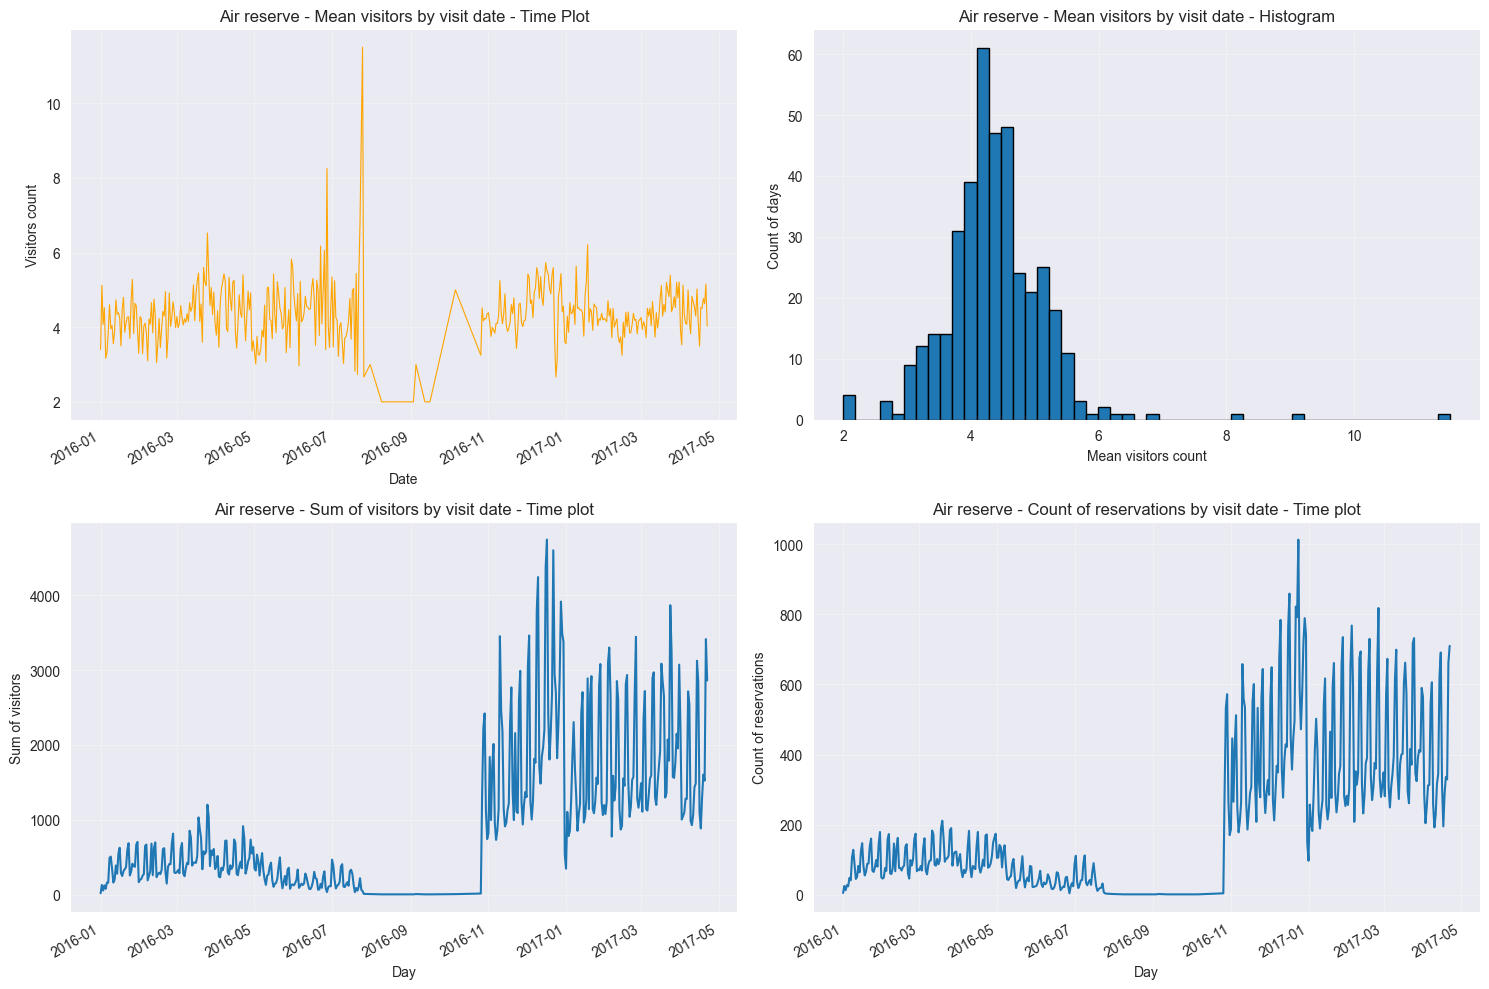

In [21]:
plot_reserve_df_distr(air_res_occurred_df, AIR_RESERVE_STR)

From August 2016 to the end of October 2016, there were no reservations. After this period, the average number of reserved visitors remained the same, but the number of reservations increased compared with the period before the gap.

### Air visit

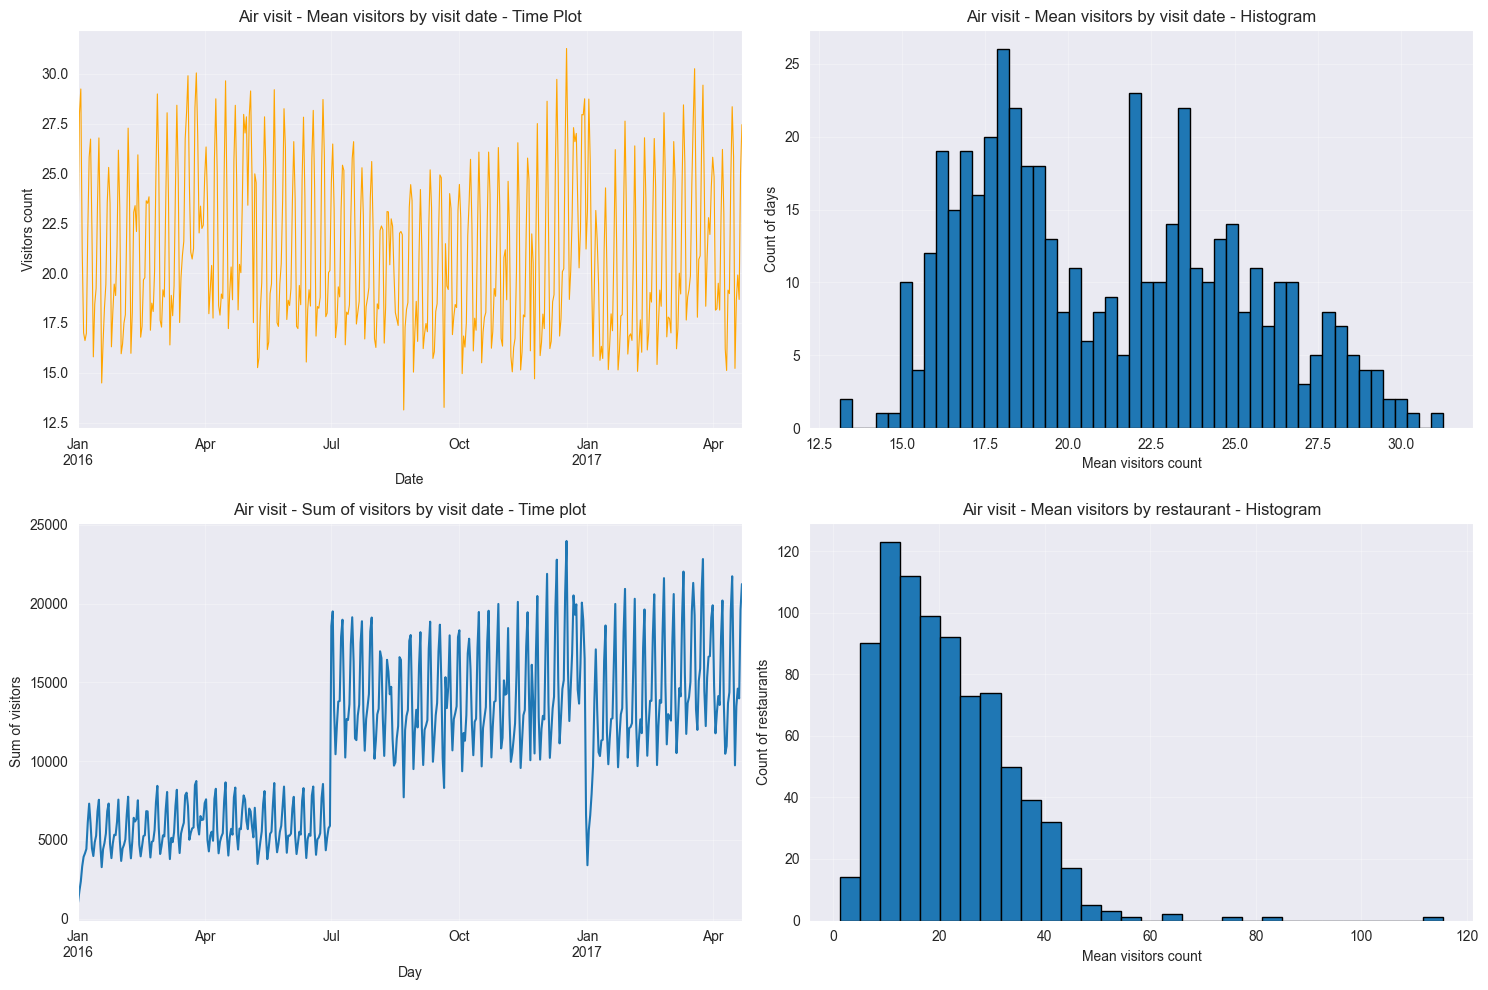

In [22]:
plot_visitors_df_distr(air_visit_df, AIR_VISIT_STR)

In July 2016, there was a jump in the "Sum of visitors by visit date" graph, which can be explained by the fact that many new restaurants opened for the first time during this period.

### Air store info

#### Location

In [23]:
plot_location_map(air_store_df)

Restaurants are distributed roughly equally across the islands of Japan.

#### Top genres & areas

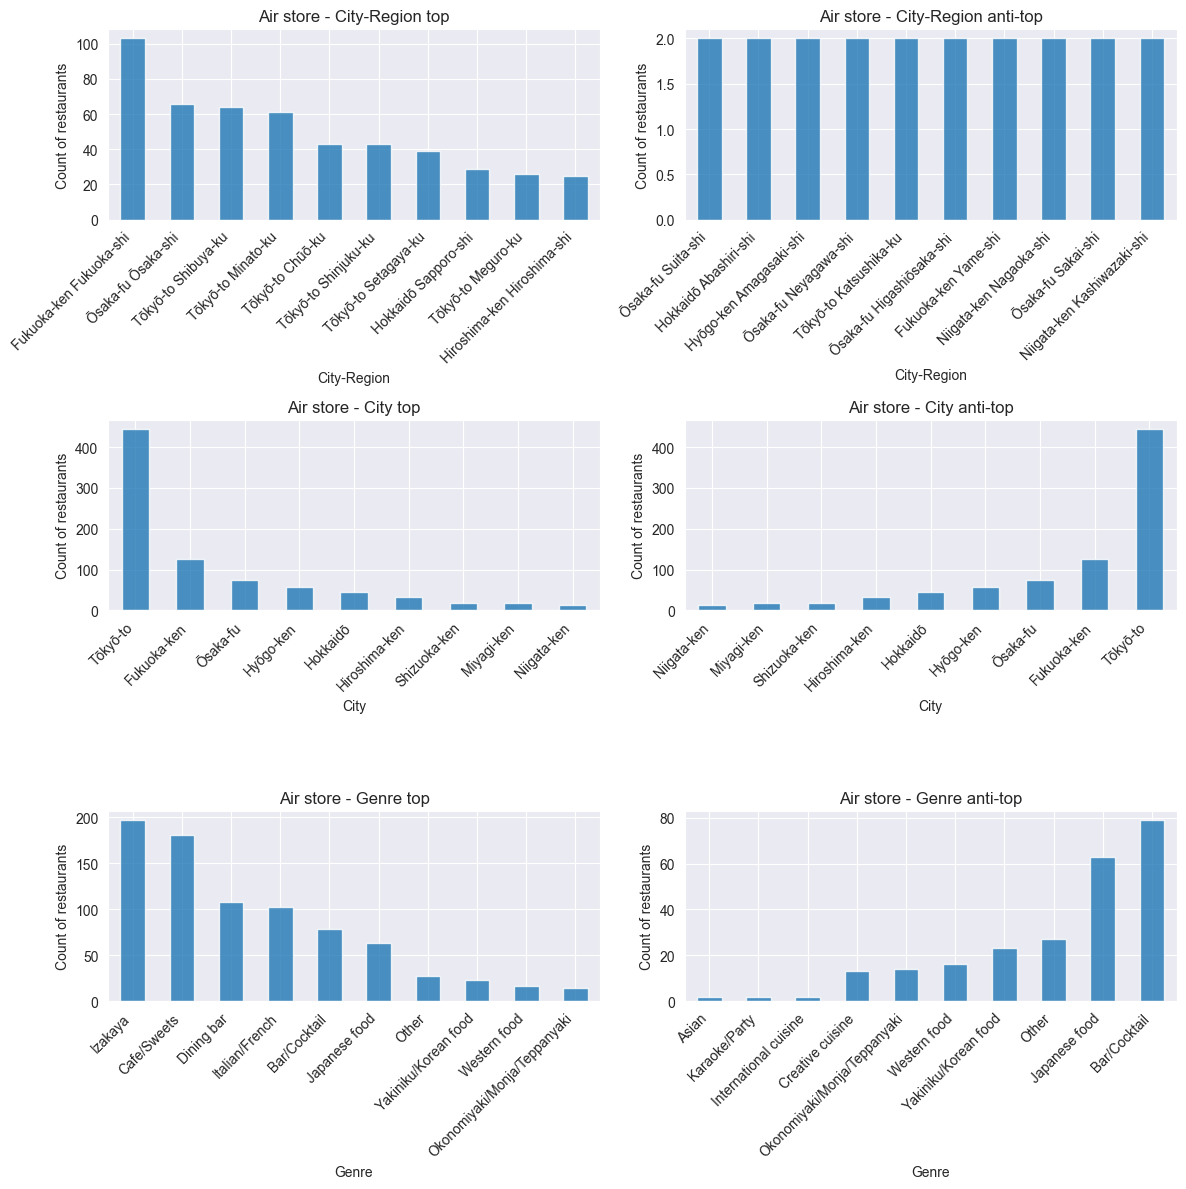

In [24]:
plot_top_genres_cities(air_store_df, AIR_STORE_STR, AIR_GENRE_COL)

At least three genres lag far behind others in popularity (number of restaurants): Asian, Karaoke/Party, and International cuisine. At the same time, there are many areas with relatively low frequency (<=2). Theoretically, the following genres can be combined: Asian and Japanese food and Okonomiaky/Monja/Teppanyaki; international cuisine and Western food; karaoke/party combined with other, since it does not combine with other genres.

In [25]:
print_low_frequency_values(air_store_df, AIR_AREA_COL, 2)
print_low_frequency_values(air_store_df, CITY_REGION_COL, 2)

Values with frequency less than 2:  46
Values with frequency less than 2:  15


About half of the areas have a maximum of 2 restaurants, while the maximum number of restaurants per area is about 60. So the best solution would be to take not the entire area, but only the city and region or only the city.

In [26]:
GENRE_REPLACEMENTS = {
    "Asian": "Japanese food",
    "Okonomiyaki/Monja/Teppanyaki": "Japanese food",
    "International cuisine": "Western food",
    "Karaoke/Party": "Other",
}
air_store_df[AIR_GENRE_COL] = air_store_df[AIR_GENRE_COL].replace(GENRE_REPLACEMENTS)

### Hpg reserve

It is necessary to consider the distribution of the number of bookings per day (visited), the average number of visitors per day (visited). Visit data that has already occurred will be taken into account.

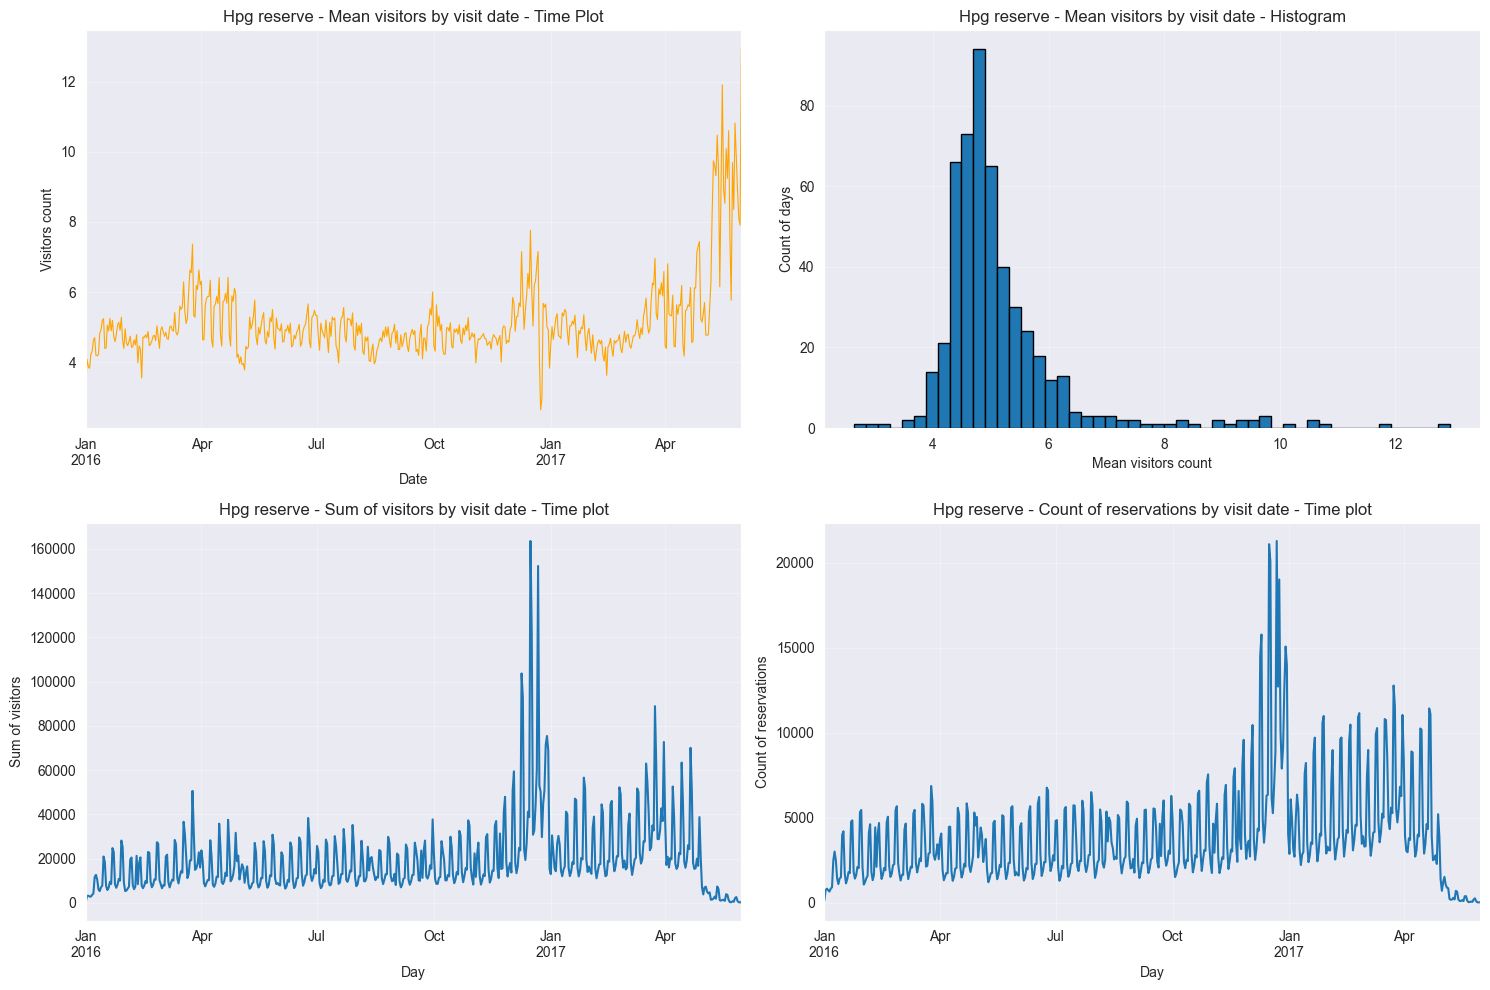

In [27]:
plot_reserve_df_distr(hpg_reserve_df, HPG_RESERVE_STR)

### Hpg store info

#### Location

In [28]:
plot_location_map(hpg_store_df)

Restaurants are distributed roughly equally across the islands of Japan, with slightly more of them in the south. We can combine Osaka (both spelled); Kanagawa, Tokyo, and Saitama. Since hpg has plenty of restaurants in each city, there's no point in combining the cities in air. Also, it makes sense to define cities for None.

#### Top genres & areas

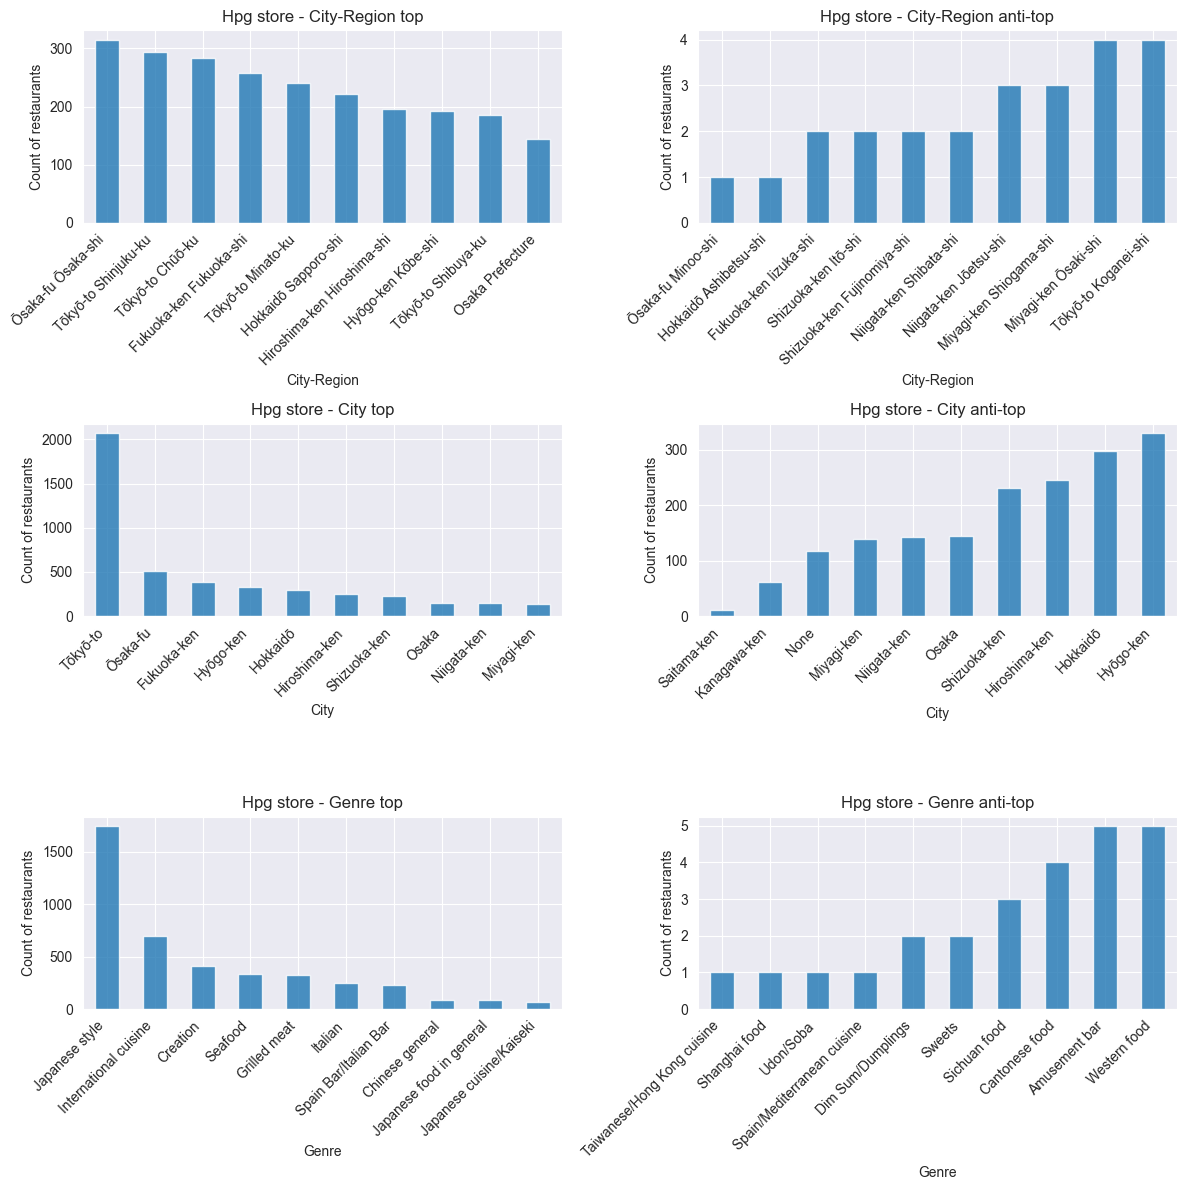

In [29]:
plot_top_genres_cities(hpg_store_df, HPG_STORE_STR, HPG_GENRE_COL)

The hpg store has genres that are less popular. There are also areas with only one restaurant.

In [30]:
print_low_frequency_values(hpg_store_df, HPG_AREA_COL, 5)
print_low_frequency_values(hpg_store_df, CITY_REGION_COL, 5)

Values with frequency less than 5:  26
Values with frequency less than 5:  12


Just under 10 percent of areas have a maximum of 2 restaurants, while just over 20 have a maximum of 5. Meanwhile, the maximum number of restaurants per area is about 250.

In [31]:
CITY_REPLACEMENTS = {
    "Osaka": "Ōsaka-fu",
    "Kanagawa-ken": "Tōkyō-to",
    "Saitama-ken": "Tōkyō-to",
}
hpg_store_df[CITY_COL] = hpg_store_df[CITY_COL].replace(CITY_REPLACEMENTS)
hpg_store_df = fill_city_by_nearest(hpg_store_df)

## Missing values

### Start/end of restaurant accounting

#### Air visit df

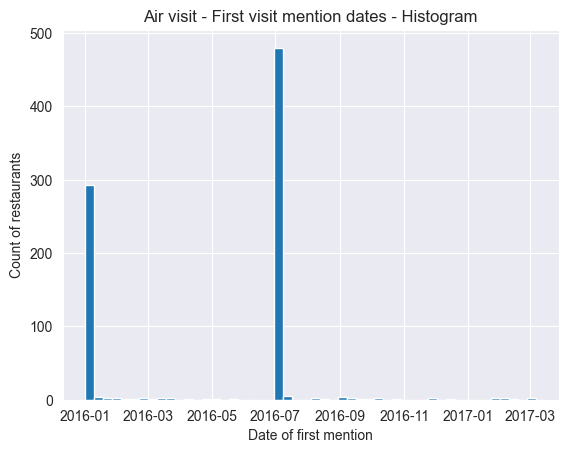

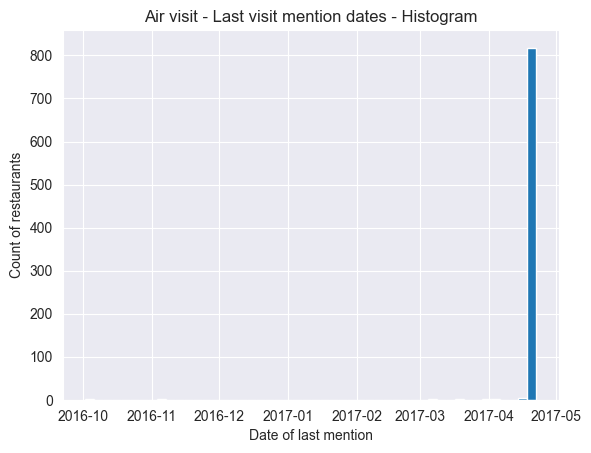

In [32]:
plot_restaurant_mention_hist(
    air_visit_df, AIR_VISIT_STR, AIR_RESTAURANT_ID_COL
)
plot_restaurant_mention_hist(
    air_visit_df, AIR_VISIT_STR, AIR_RESTAURANT_ID_COL, first=False
)

The graph shows that a large number of restaurants did not open immediately (in January 2016), but began somewhat later after the minimum visit date. The month with the highest frequency of openings was July 2016.

Almost all restaurants are mentioned for the last time on the latest possible date. However, it's important to note that there are also a small number that closed much earlier.

#### Air reserve df

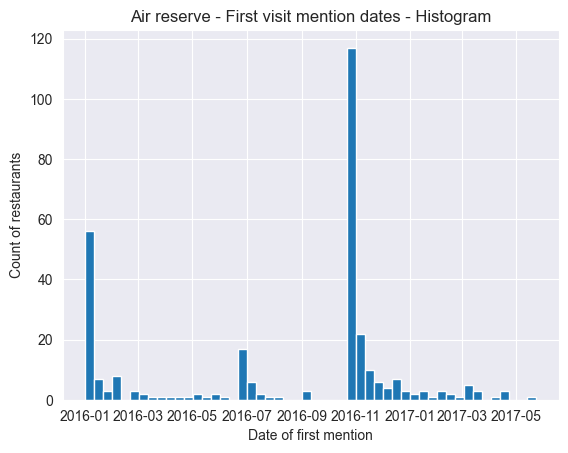

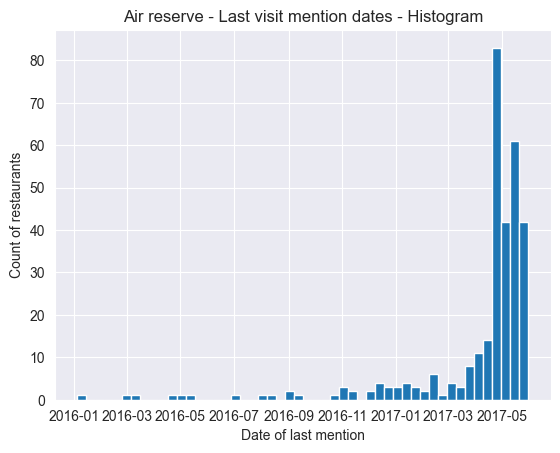

In [33]:
plot_restaurant_mention_hist(
    air_reserve_df, AIR_RESERVE_STR, AIR_RESTAURANT_ID_COL
)
plot_restaurant_mention_hist(
    air_reserve_df, AIR_RESERVE_STR, AIR_RESTAURANT_ID_COL, first=False
)

The graph shows that some restaurants are mentioned for the first time already in the predicted data. Most restaurants are last mentioned either on the earliest possible date that has already occurred, or during the dates for which data needs to be forecasted. However, there are quite a few restaurants that closed during the entire time period.

#### Hpg reserve df

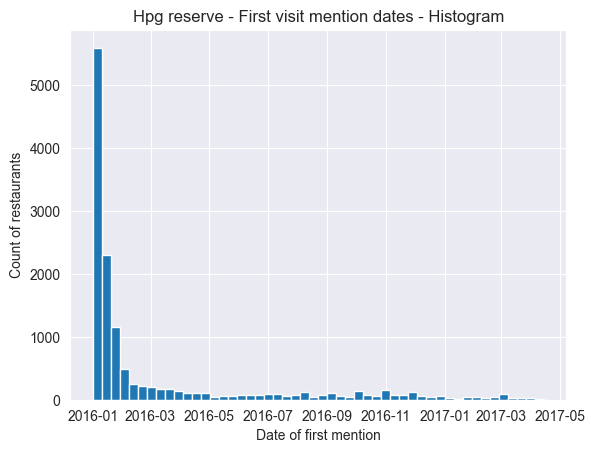

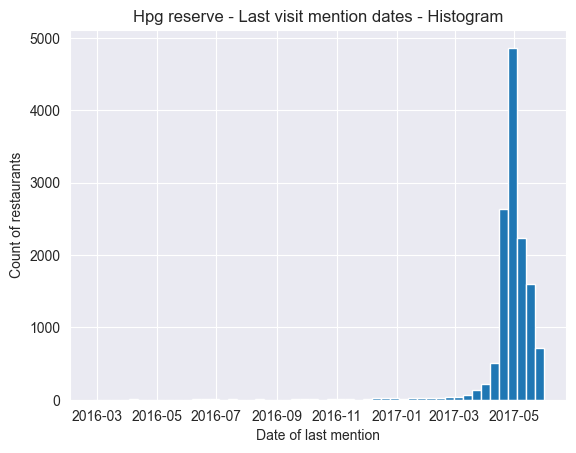

In [34]:
plot_restaurant_mention_hist(
    hpg_reserve_df, HPG_RESERVE_STR, HPG_RESTAURANT_ID_COL
)
plot_restaurant_mention_hist(
    hpg_reserve_df, HPG_RESERVE_STR, HPG_RESTAURANT_ID_COL, first=False
)

Most of the restaurants opened early (January 2016), but some still opened later. Here, as in the air reserve df, most restaurants are last mentioned on the last dates or on the dates for which forecast data is needed. There are also restaurants that closed during the entire time period, but their percentage is quite small compared to air reserve.

### Missing dates

It's necessary to consider the percentage of missed dates for restaurants. However, some restaurants opened later than others, so two cases need to be considered: one with all dates missing, regardless of the opening date, and the other with this factor in.

#### Air visit df

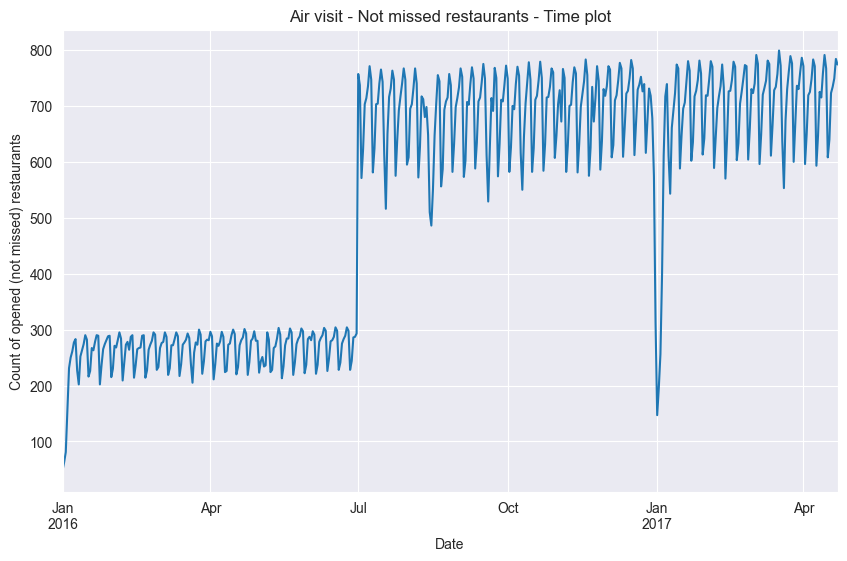

In [35]:
plot_opened_restaurants(
    air_visit_df.groupby(VISIT_DATE_COL)[AIR_RESTAURANT_ID_COL].count(),
    AIR_VISIT_STR
)

There is a seasonal pattern in the missing dates. However, July 2016 saw a spike due to the opening (or first mention) of a large number of restaurants. Also in January 2017, a large number of restaurants were missed (there was a drop and spike).

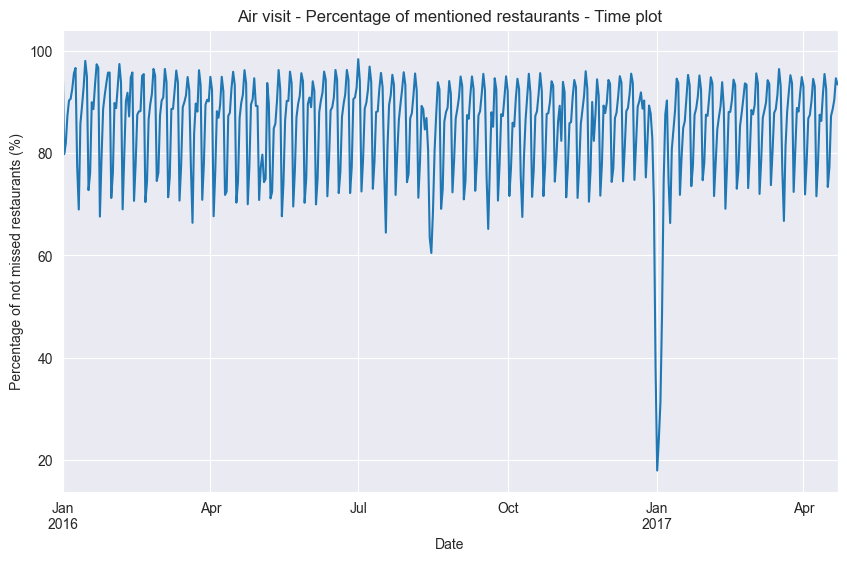

In [36]:
air_vis_msd_per_df = get_opened_restaurants_pct(
    air_visit_df, VISIT_DATE_COL, AIR_RESTAURANT_ID_COL
)
plot_opened_restaurants_pct(air_vis_msd_per_df[PERCENTAGE_COL], AIR_VISIT_STR)

The graph shows seasonality in restaurant closures. However, unlike the previous graph, there is no rise in July (due to the number of restaurants not mentioned yet). A drop and spike are also visible in January 2017.

#### Air reserve & hpg reserve correlation

To be able to use data from hpg to fill in the gaps in air reserve, need to see how they compare.

In [37]:
hpg_reserve_df = hpg_reserve_df.merge(
    store_id_rel_df,
    on=HPG_RESTAURANT_ID_COL,
    how="left",
)

In [38]:
air_res_filled = fill_missing_dates(
    air_reserve_df,
    VISIT_DATE_COL,
    AIR_RESTAURANT_ID_COL,
    RESERVE_VISITORS_COL,
)
hpg_res_filled = fill_missing_dates(
    hpg_reserve_df,
    VISIT_DATE_COL,
    HPG_RESTAURANT_ID_COL,
    RESERVE_VISITORS_COL,
)

Correlation: 0.7262


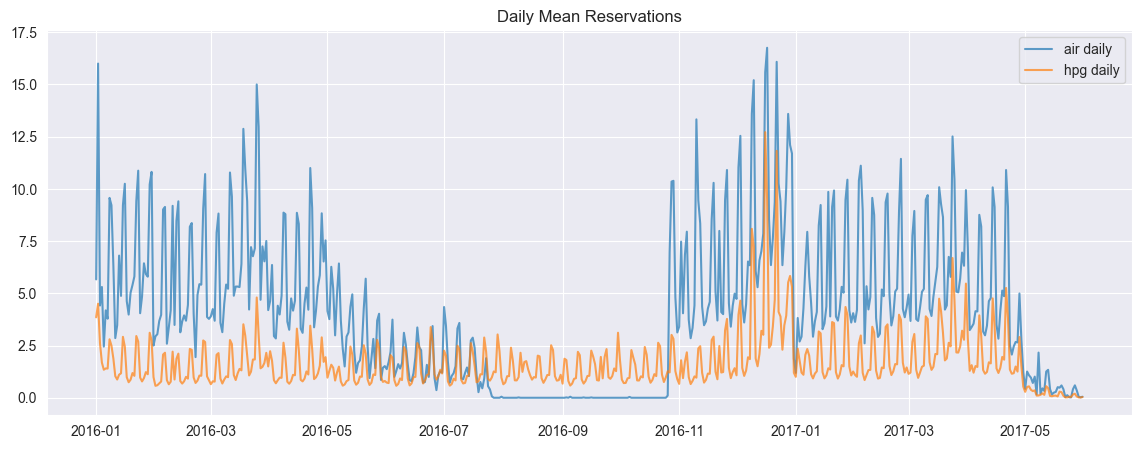

In [39]:
corr, air_hpg_combined = get_dfs_daily_corr(
    air_res_filled, hpg_res_filled
)

print(f"Correlation: {corr:.4f}")

plot_daily_corr(air_hpg_combined, AIR_DAILY_COL, HPG_DAILY_COL)

The correlation above was taken across all dates, including air_reserve gaps. It's necessary to look at the correlation without taking them into account.

In [40]:
corr, air_hpg_combined = get_dfs_daily_corr(
    air_res_filled, hpg_res_filled, EMPTY_DATES_RANGE
)

print(f"Correlation: {corr:.4f}")

Correlation: 0.8048


It is possible to attempt imputing the missing values, but the method should also incorporate historical data and seasonal patterns.

Correlation: 0.8055


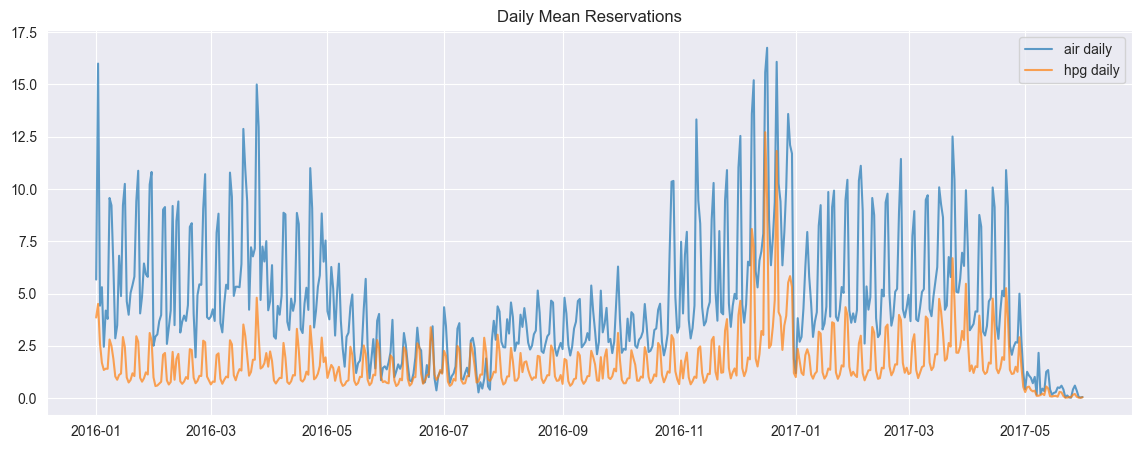

In [41]:
corr, air_hpg_combined = get_dfs_daily_corr(
    fill_air_res_gaps(air_res_filled, hpg_res_filled, EMPTY_DATES_RANGE), hpg_res_filled
)

print(f"Correlation: {corr:.4f}")

plot_daily_corr(air_hpg_combined, AIR_DAILY_COL, HPG_DAILY_COL)

In [42]:
del corr, air_hpg_combined

### Filling dates

There were already reservations for some dates preceding the "opening".

In [43]:
air_res_min = get_first_dates(air_res_filled, AIR_RESTAURANT_ID_COL)
air_visit_min = get_first_dates(air_visit_df, AIR_RESTAURANT_ID_COL)
hpg_air_min = get_first_dates(hpg_res_filled, AIR_RESTAURANT_ID_COL)

In [44]:
air_min = (
    pd.concat([air_res_min, air_visit_min, hpg_air_min], axis=1)
    .min(axis=1)
    .rename(VISIT_DATE_COL)
)

In [45]:
print_df_len(air_visit_df, AIR_VISIT_STR)
air_visit_full = fill_missing_dates(
    air_visit_df, VISIT_DATE_COL, AIR_RESTAURANT_ID_COL, VISITORS_COL, air_min
)
print_df_len(air_visit_full, AIR_VISIT_STR + " filled")

Air visit count of rows: 252108
Air visit filled count of rows: 313933


In [46]:
air_visit_prep = fill_missing_dates(
    air_visit_df, VISIT_DATE_COL, AIR_RESTAURANT_ID_COL, VISITORS_COL
)
air_visit_prep.to_csv(INTERIM_DATA_DIR / "air_visit.csv", index=False)
hpg_res_filled.to_csv(INTERIM_DATA_DIR / "hpg_reserve.csv", index=False)
fill_air_res_gaps(air_res_filled, hpg_res_filled, EMPTY_DATES_RANGE).to_csv(INTERIM_DATA_DIR / "air_reserve.csv", index=False)
sample_submission_df.to_csv(INTERIM_DATA_DIR / "sample_submission.csv", index=False)
air_store_df.drop(columns=[CITY_REGION_COL]).to_csv(INTERIM_DATA_DIR / "air_store_info.csv", index=False)
hpg_store_df.drop(columns=[CITY_REGION_COL]).to_csv(INTERIM_DATA_DIR / "hpg_store_info.csv", index=False)

### Dates info

It is necessary to check that all dates for the specified period are presented in date info df.

In [47]:
date_info_uniq_dates = date_info_df[CALENDAR_DATE_COL].unique()

for df, df_str in zip(
    [air_visit_full, air_res_filled, hpg_res_filled],
    [AIR_VISIT_STR, AIR_RESERVE_STR, HPG_RESERVE_STR],
):
    df_uniq_dates = df[VISIT_DATE_COL].unique()
    print(
        f"All {df_str} dates in date info: ",
        all(df_uniq_dates.isin(date_info_uniq_dates)),
    )

All Air visit dates in date info:  True
All Air reserve dates in date info:  True
All Hpg reserve dates in date info:  True


In [48]:
del date_info_uniq_dates, df, df_str

## Problematic data

### Number of visitors & number of reserved visitors

#### Air reserve & air visit

There may be cases when the number of planned visitors for a reservation (air reserve) exceeds the final number of visitors (air visit).

In [49]:
air_problematic_rows, air_visit_air_res = find_reservations_exceed_visitors(
    air_res_occurred_df,
    air_visit_full,
    AIR_RESTAURANT_ID_COL,
    VISIT_DATE_COL,
    RESERVE_VISITORS_COL,
    VISITORS_COL,
)
print_df_len(air_res_occurred_df, AIR_RESERVE_STR)
print_df_len(air_visit_full, AIR_VISIT_STR)
print_df_len(air_visit_air_res, "Merged")
print_problematic_rows(air_problematic_rows)

Air reserve count of rows: 90585
Air visit count of rows: 313933
Merged count of rows: 313933
Found 1781 problematic rows


,visit_date,air_store_id,visitors,reserve_visitors
504,2016-11-11,air_0164b9927d20bcc3,3,4.0
626,2017-03-13,air_0164b9927d20bcc3,9,11.0
2574,2016-03-19,air_03963426c9312048,60,64.0
2797,2016-10-28,air_03963426c9312048,38,54.0
2825,2016-11-25,air_03963426c9312048,57,78.0


#### Air visit & hpg reserve

In [50]:
air_visit_hpg_merged = pd.merge(
    air_visit_full,
    store_id_rel_df,
    on=[AIR_RESTAURANT_ID_COL],
    how='inner',
)
hpg_res_air_merged = pd.merge(
    hpg_res_occurred_df,
    store_id_rel_df,
    on=[HPG_RESTAURANT_ID_COL],
    how='inner',
)
print_df_len(air_visit_full, AIR_VISIT_STR)
print_df_len(store_id_rel_df, AIR_STORE_REL_STR)
print_df_len(air_visit_hpg_merged, "Air visit (IDs have hpg relation)")
print_df_len(hpg_res_occurred_df, HPG_RESERVE_STR)
print_df_len(hpg_res_air_merged, "Hpg reserve (IDs have air relation)")

Air visit count of rows: 313933
Air store relation count of rows: 150
Air visit (IDs have hpg relation) count of rows: 69567
Hpg reserve count of rows: 1964671
Hpg reserve (IDs have air relation) count of rows: 27767


In [51]:
hpg_problematic_rows, air_visit_hpg_res = find_reservations_exceed_visitors(
    hpg_res_air_merged,  # 27767 rows
    air_visit_hpg_merged,  # 69567 rows
    HPG_RESTAURANT_ID_COL,
    VISIT_DATE_COL,
    RESERVE_VISITORS_COL,
    VISITORS_COL,
)
print_df_len(air_visit_hpg_res, "Merged")
print_problematic_rows(hpg_problematic_rows)

Merged count of rows: 69567
Found 5288 problematic rows


,visit_date,hpg_store_id,visitors,reserve_visitors
0,2016-01-09,hpg_0183ec352e38903c,0,2.0
2,2016-01-11,hpg_0183ec352e38903c,0,8.0
5,2016-01-14,hpg_0183ec352e38903c,0,11.0
6,2016-01-15,hpg_0183ec352e38903c,0,8.0
9,2016-01-18,hpg_0183ec352e38903c,0,9.0


In [52]:
air_visit_hpg_res.head()

,air_store_id,visit_date,visitors,hpg_store_id,reserve_visitors
0,air_cbe867adcf44e14f,2016-01-09,0,hpg_0183ec352e38903c,2.0
1,air_cbe867adcf44e14f,2016-01-10,0,hpg_0183ec352e38903c,0.0
2,air_cbe867adcf44e14f,2016-01-11,0,hpg_0183ec352e38903c,8.0
3,air_cbe867adcf44e14f,2016-01-12,0,hpg_0183ec352e38903c,0.0
4,air_cbe867adcf44e14f,2016-01-13,0,hpg_0183ec352e38903c,0.0


#### Air visit & air reserve & hpg reserve

In [53]:
all_merged = pd.merge(
    air_visit_hpg_res,  # 69567 rows
    air_visit_air_res,  # 313933 rows
    on=[AIR_RESTAURANT_ID_COL, VISIT_DATE_COL, VISITORS_COL],
    how="outer",
    suffixes=(HPG_SUFFIX, AIR_SUFFIX),
).rename(columns={
    RESERVE_VISITORS_COL + HPG_SUFFIX: RESERVE_HPG_COL,
    RESERVE_VISITORS_COL + AIR_SUFFIX: RESERVE_AIR_COL,
})
print_df_len(all_merged, "Air visit & hpg res & air res")

Air visit & hpg res & air res count of rows: 313933


In [54]:
columns = [VISIT_DATE_COL, AIR_RESTAURANT_ID_COL, VISITORS_COL, RESERVE_HPG_COL, RESERVE_AIR_COL, VISITORS_DIFF_COL]

all_merged = all_merged.fillna(0)
all_merged[VISITORS_DIFF_COL] = (
    all_merged[RESERVE_HPG_COL] + all_merged[RESERVE_AIR_COL] - all_merged[VISITORS_COL]
)

print_problematic_rows(all_merged[all_merged[VISITORS_DIFF_COL] > 0][columns])

Found 8125 problematic rows


,visit_date,air_store_id,visitors,hpg_reserves,air_reserves,visitors_difference
0,2016-01-14,air_00a91d42b08b08d9,0,2.0,0.0,2.0
1,2016-01-15,air_00a91d42b08b08d9,0,4.0,0.0,4.0
2,2016-01-16,air_00a91d42b08b08d9,0,2.0,0.0,2.0
8,2016-01-22,air_00a91d42b08b08d9,0,2.0,0.0,2.0
15,2016-01-29,air_00a91d42b08b08d9,0,5.0,0.0,5.0


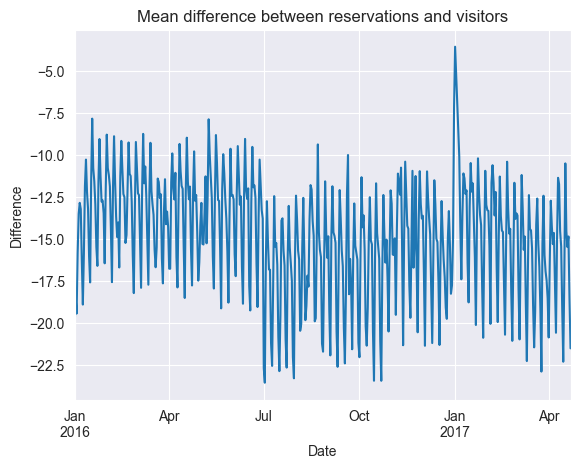

In [55]:
plot_mean_diff_by_date(all_merged.groupby(VISIT_DATE_COL)[VISITORS_DIFF_COL].mean())

It turns out that usually more people actually come to the restaurant than were booked (since the difference on the graph is negative).

In [56]:
del (
    air_problematic_rows,
    air_visit_air_res,
    air_visit_hpg_merged,
    hpg_res_air_merged,
    hpg_problematic_rows,
    air_visit_hpg_res,
    all_merged,
    columns,
)

### Reserve dates greater than visit dates

It is necessary to check the dataframes for date errors: are there any rows where the reservation datetime is greater than the visit datetime?

#### Air reserve

In [57]:
filter_by_column_comparison(air_res_filled, RESERVE_DATETIME_COL, VISIT_DATETIME_COL)

,air_store_id,visit_date,visit_datetime,reserve_datetime,reserve_visitors


There are no rows in the dataframe where the reservation datetime is greater than the visit datetime.

#### Hpg reserve

In [58]:
filter_by_column_comparison(hpg_res_filled, RESERVE_DATETIME_COL, VISIT_DATETIME_COL)

,hpg_store_id,visit_date,visit_datetime,reserve_datetime,reserve_visitors,air_store_id


There are no rows in the dataframe where the reservation datetime is greater than the visit datetime.

### Data incompatibility between the air store info and hpg store info

The following problem may arise: air store info may contain one type of restaurant data (genre and region), while hpg may contain different data.

In [59]:
air_hpg_genre_merged = store_id_rel_df.merge(
    air_store_df,
    on=[AIR_RESTAURANT_ID_COL],
    how="inner"
).merge(
    hpg_store_df,
    on=[HPG_RESTAURANT_ID_COL],
    how="inner"
)

In [60]:
print("Count of rows:", len(air_hpg_genre_merged))

Count of rows: 63


In [61]:
genre_not_matched = air_hpg_genre_merged[
    air_hpg_genre_merged[AIR_GENRE_COL] != air_hpg_genre_merged[HPG_GENRE_COL]
]
print_problematic_rows(genre_not_matched)

Found 63 problematic rows


,air_store_id,hpg_store_id,air_genre_name,air_area_name,latitude_x,longitude_x,city_region_x,city_x,hpg_genre_name,hpg_area_name,latitude_y,longitude_y,city_region_y,city_y
0,air_a24bf50c3e90d583,hpg_c34b496d0305a809,Dining bar,Shizuoka-ken Hamamatsu-shi Motoshirochō,34.710895,137.725940,Shizuoka-ken Hamamatsu-shi,Shizuoka-ken,Italian,Shizuoka-ken Hamamatsu-shi Sukenobuchō,34.721644,137.738944,Shizuoka-ken Hamamatsu-shi,Shizuoka-ken
1,air_a38f25e3399d1b25,hpg_50378da9ffb9b6cd,Izakaya,Tōkyō-to Chiyoda-ku Kudanminami,35.694003,139.753595,Tōkyō-to Chiyoda-ku,Tōkyō-to,Japanese style,Tōkyō-to Chiyoda-ku None,35.695780,139.768453,Tōkyō-to Chiyoda-ku,Tōkyō-to
2,air_3c938075889fc059,hpg_349b1b92f98b175e,Japanese food,Fukuoka-ken Fukuoka-shi Daimyō,33.589216,130.392813,Fukuoka-ken Fukuoka-shi,Fukuoka-ken,Japanese style,Fukuoka-ken Fukuoka-shi Ōmiya,33.579734,130.401762,Fukuoka-ken Fukuoka-shi,Fukuoka-ken
3,air_ef789667e2e6fe96,hpg_f76ad2d2d0134bdd,Dining bar,Tōkyō-to Machida-shi Morino,35.546631,139.438619,Tōkyō-to Machida-shi,Tōkyō-to,International cuisine,Tōkyō-to Machida-shi Nakamachi,35.549670,139.448494,Tōkyō-to Machida-shi,Tōkyō-to
4,air_8f3b563416efc6ad,hpg_d12fb3b2b4129cd6,Izakaya,Tōkyō-to Shinjuku-ku Kabukichō,35.693840,139.703549,Tōkyō-to Shinjuku-ku,Tōkyō-to,Creative Japanese food,Tōkyō-to Shinjuku-ku None,35.691384,139.701256,Tōkyō-to Shinjuku-ku,Tōkyō-to


Almost all restaurants do not have the same genre in air and hpg systems.

In [62]:
area_not_matched = air_hpg_genre_merged[
    air_hpg_genre_merged[AIR_AREA_COL] != air_hpg_genre_merged[HPG_AREA_COL]
]
print_problematic_rows(area_not_matched)

Found 58 problematic rows


,air_store_id,hpg_store_id,air_genre_name,air_area_name,latitude_x,longitude_x,city_region_x,city_x,hpg_genre_name,hpg_area_name,latitude_y,longitude_y,city_region_y,city_y
0,air_a24bf50c3e90d583,hpg_c34b496d0305a809,Dining bar,Shizuoka-ken Hamamatsu-shi Motoshirochō,34.710895,137.725940,Shizuoka-ken Hamamatsu-shi,Shizuoka-ken,Italian,Shizuoka-ken Hamamatsu-shi Sukenobuchō,34.721644,137.738944,Shizuoka-ken Hamamatsu-shi,Shizuoka-ken
1,air_a38f25e3399d1b25,hpg_50378da9ffb9b6cd,Izakaya,Tōkyō-to Chiyoda-ku Kudanminami,35.694003,139.753595,Tōkyō-to Chiyoda-ku,Tōkyō-to,Japanese style,Tōkyō-to Chiyoda-ku None,35.695780,139.768453,Tōkyō-to Chiyoda-ku,Tōkyō-to
2,air_3c938075889fc059,hpg_349b1b92f98b175e,Japanese food,Fukuoka-ken Fukuoka-shi Daimyō,33.589216,130.392813,Fukuoka-ken Fukuoka-shi,Fukuoka-ken,Japanese style,Fukuoka-ken Fukuoka-shi Ōmiya,33.579734,130.401762,Fukuoka-ken Fukuoka-shi,Fukuoka-ken
3,air_ef789667e2e6fe96,hpg_f76ad2d2d0134bdd,Dining bar,Tōkyō-to Machida-shi Morino,35.546631,139.438619,Tōkyō-to Machida-shi,Tōkyō-to,International cuisine,Tōkyō-to Machida-shi Nakamachi,35.549670,139.448494,Tōkyō-to Machida-shi,Tōkyō-to
4,air_8f3b563416efc6ad,hpg_d12fb3b2b4129cd6,Izakaya,Tōkyō-to Shinjuku-ku Kabukichō,35.693840,139.703549,Tōkyō-to Shinjuku-ku,Tōkyō-to,Creative Japanese food,Tōkyō-to Shinjuku-ku None,35.691384,139.701256,Tōkyō-to Shinjuku-ku,Tōkyō-to


Almost all restaurants also have a mismatch in the area. But these are partial discrepancies: the last word or number may differ.

In [63]:
not_matched = pd.concat([area_not_matched, genre_not_matched]).drop_duplicates()
print_problematic_rows(not_matched)

Found 63 problematic rows


,air_store_id,hpg_store_id,air_genre_name,air_area_name,latitude_x,longitude_x,city_region_x,city_x,hpg_genre_name,hpg_area_name,latitude_y,longitude_y,city_region_y,city_y
0,air_a24bf50c3e90d583,hpg_c34b496d0305a809,Dining bar,Shizuoka-ken Hamamatsu-shi Motoshirochō,34.710895,137.725940,Shizuoka-ken Hamamatsu-shi,Shizuoka-ken,Italian,Shizuoka-ken Hamamatsu-shi Sukenobuchō,34.721644,137.738944,Shizuoka-ken Hamamatsu-shi,Shizuoka-ken
1,air_a38f25e3399d1b25,hpg_50378da9ffb9b6cd,Izakaya,Tōkyō-to Chiyoda-ku Kudanminami,35.694003,139.753595,Tōkyō-to Chiyoda-ku,Tōkyō-to,Japanese style,Tōkyō-to Chiyoda-ku None,35.695780,139.768453,Tōkyō-to Chiyoda-ku,Tōkyō-to
2,air_3c938075889fc059,hpg_349b1b92f98b175e,Japanese food,Fukuoka-ken Fukuoka-shi Daimyō,33.589216,130.392813,Fukuoka-ken Fukuoka-shi,Fukuoka-ken,Japanese style,Fukuoka-ken Fukuoka-shi Ōmiya,33.579734,130.401762,Fukuoka-ken Fukuoka-shi,Fukuoka-ken
3,air_ef789667e2e6fe96,hpg_f76ad2d2d0134bdd,Dining bar,Tōkyō-to Machida-shi Morino,35.546631,139.438619,Tōkyō-to Machida-shi,Tōkyō-to,International cuisine,Tōkyō-to Machida-shi Nakamachi,35.549670,139.448494,Tōkyō-to Machida-shi,Tōkyō-to
4,air_8f3b563416efc6ad,hpg_d12fb3b2b4129cd6,Izakaya,Tōkyō-to Shinjuku-ku Kabukichō,35.693840,139.703549,Tōkyō-to Shinjuku-ku,Tōkyō-to,Creative Japanese food,Tōkyō-to Shinjuku-ku None,35.691384,139.701256,Tōkyō-to Shinjuku-ku,Tōkyō-to


Absolutely all restaurants have a discrepancy at least in genre or in area in the air and hpg systems.

In [64]:
del (
    air_hpg_genre_merged,
    genre_not_matched,
    area_not_matched,
    not_matched,
)

## Data distribution after filling

### Air visit df

It is necessary to consider the distribution of visitors for the date, the distribution of visitors for each restaurant, and outliers.

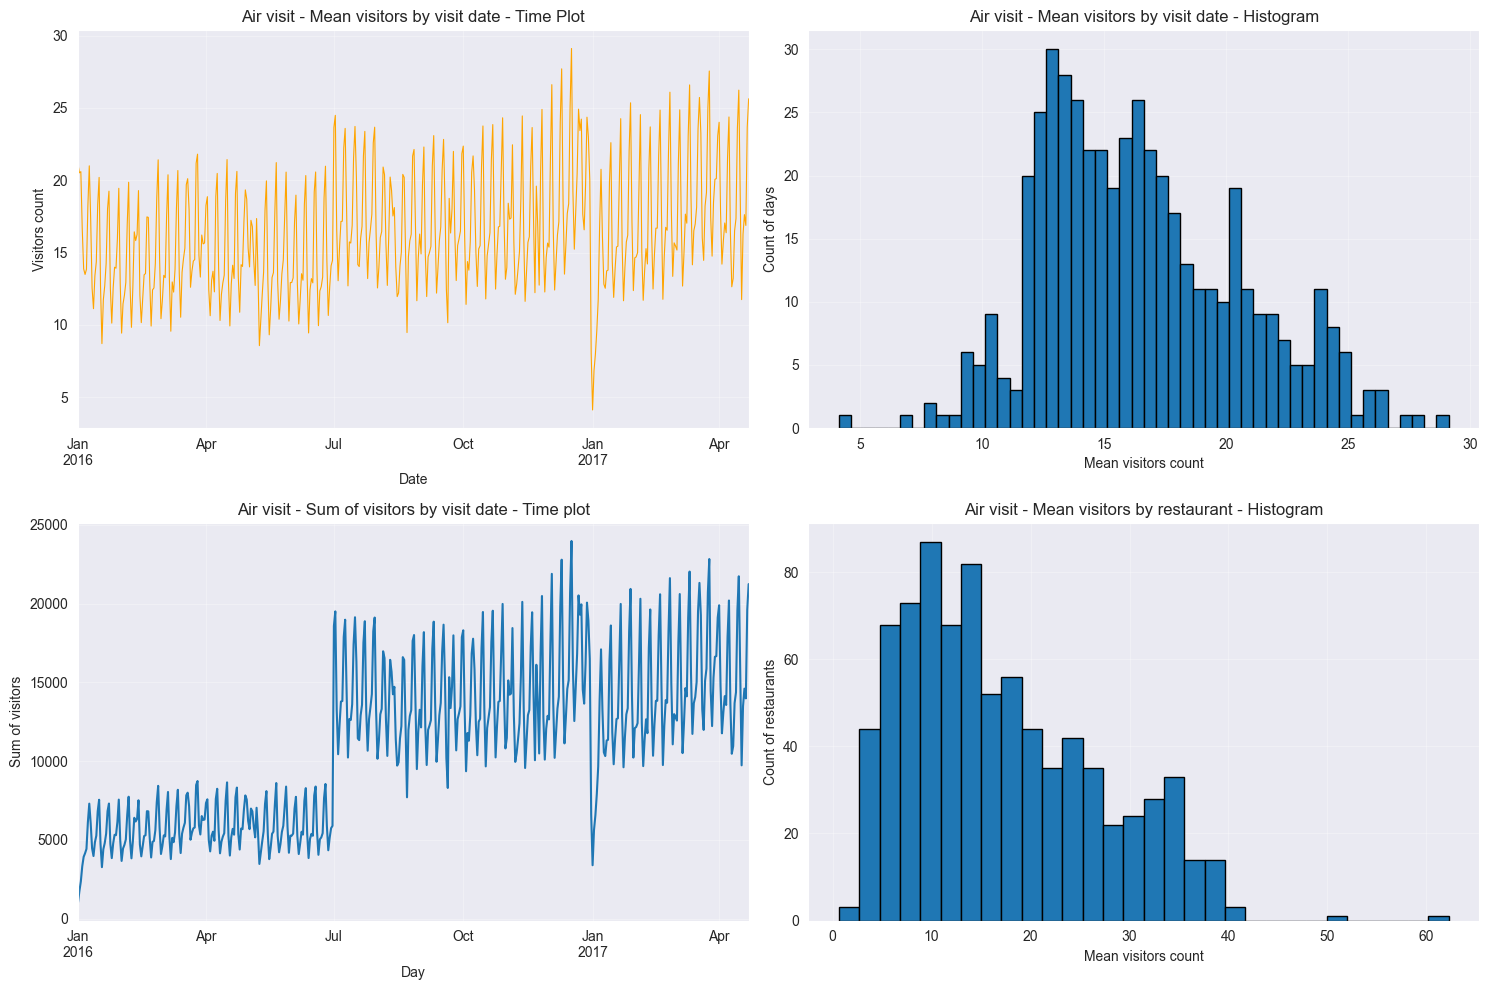

In [65]:
plot_visitors_df_distr(air_visit_full, AIR_VISIT_STR)

There is some seasonality in the data. In the graph "visitors by date - histogram" the distribution is possibly multimodal. This may be due to the influence of holidays and non-holidays.

### Air store info

#### Top genres & areas

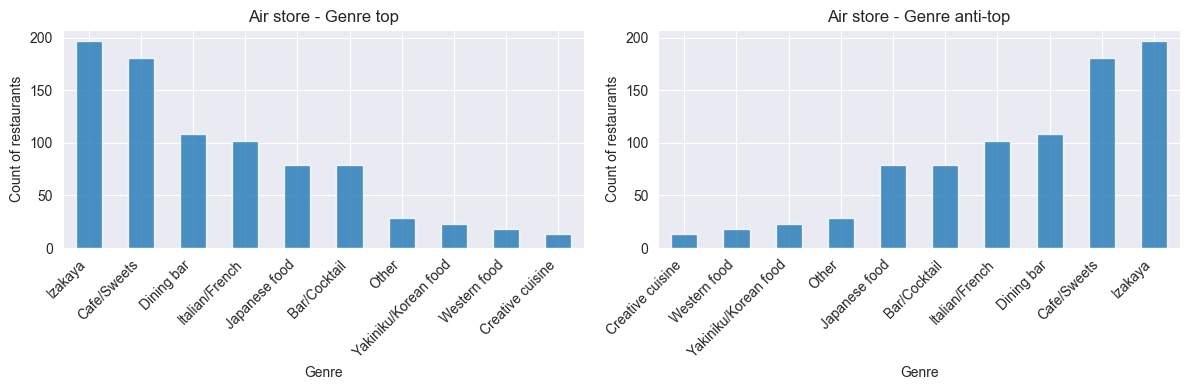

In [66]:
plot_top_genres_cities(air_store_df, AIR_STORE_STR, AIR_GENRE_COL, "genre")

In [67]:
air_vis_with_info = air_visit_full.merge(
    air_store_df, on=AIR_RESTAURANT_ID_COL, how="inner"
)

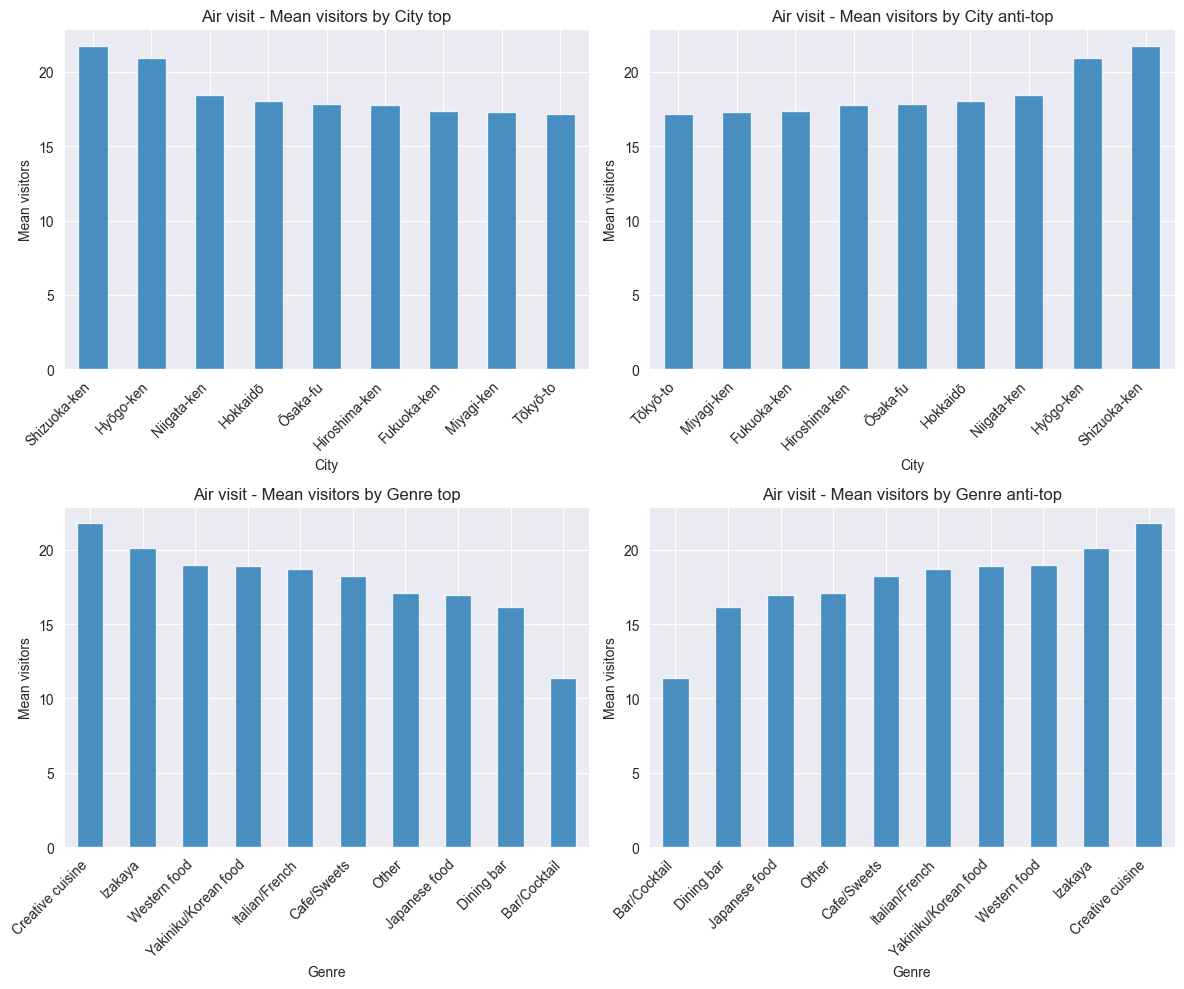

In [68]:
max_date = air_vis_with_info[VISIT_DATE_COL].max()
air_vis_last_months = air_vis_with_info[
    air_vis_with_info[VISIT_DATE_COL] >= max_date - pd.DateOffset(months=6)
]
plot_visitors_by_genre_city(air_vis_last_months, AIR_VISIT_STR)

In [69]:
del air_vis_last_months

### Hpg reserve

It is necessary to consider the distribution of the number of bookings per day (visited), the average number of visitors per day (visited). Visit data that has already occurred will be taken into account.

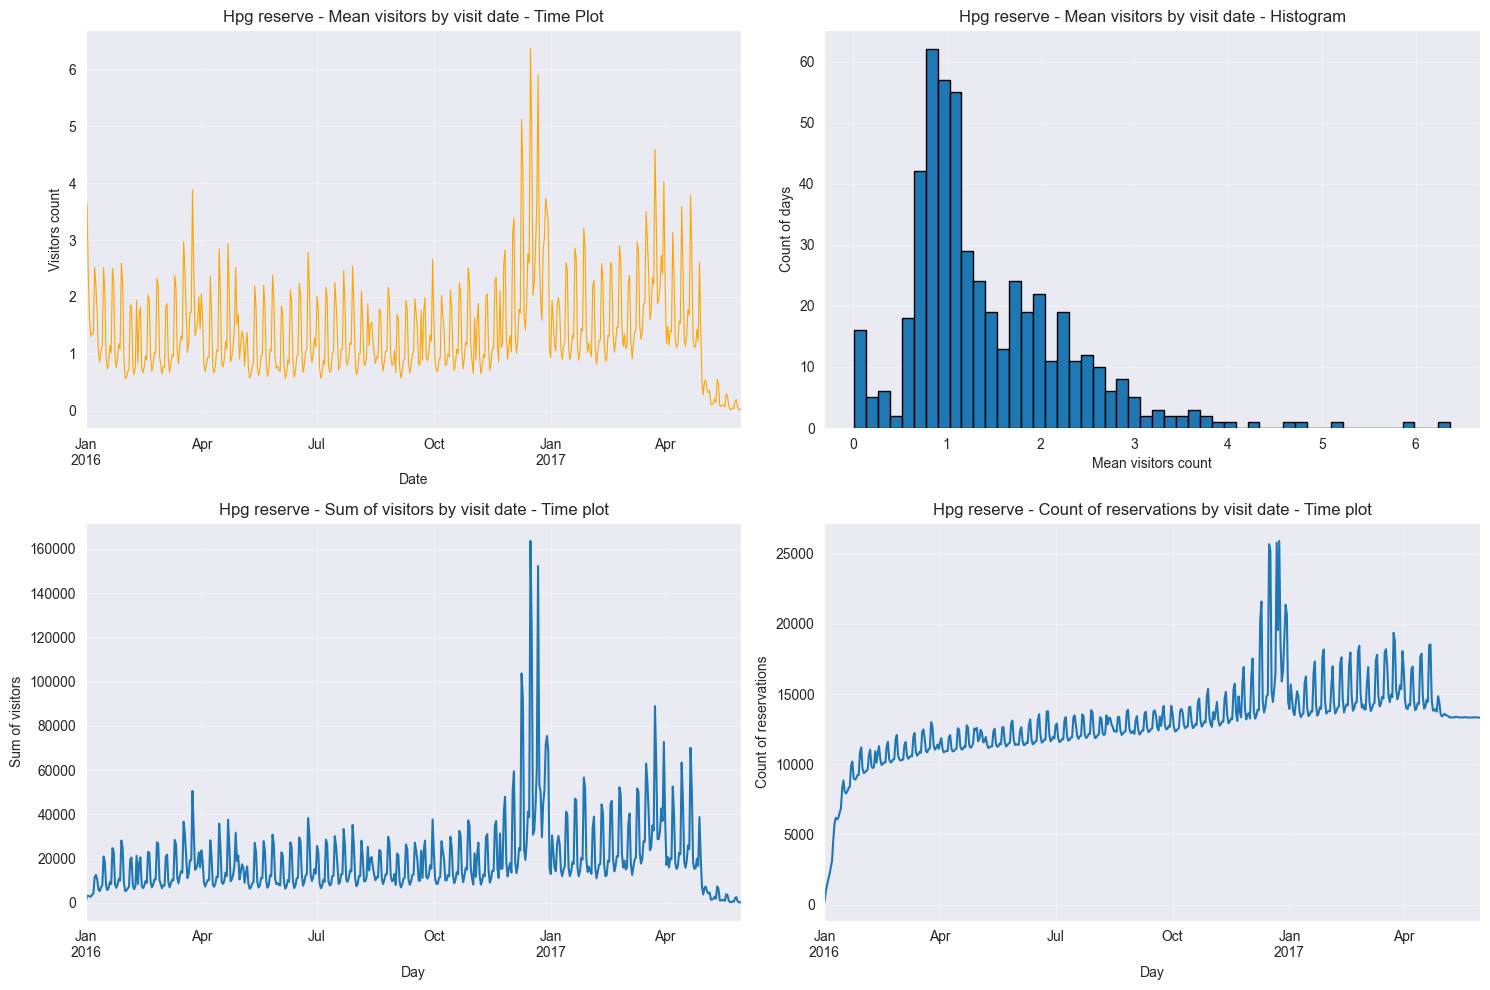

In [70]:
plot_reserve_df_distr(hpg_res_filled, HPG_RESERVE_STR)

In graph "Mean visitors by date - Time Plot", in April 2016 and 2017, and December 2017, there were spikes in the average number of visitors per day. In January there is a sharp drop (for a couple of days), after which the values return to normal.
In graph "Count of reservations by visit date - Time Plot", there is seasonality for count of reservations per day, but December 2017 shows a significant spike. By January 2017, the values return to normal, but over time until April they gradually increase on average.

### Hpg store info

In [71]:
plot_location_map(hpg_store_df)

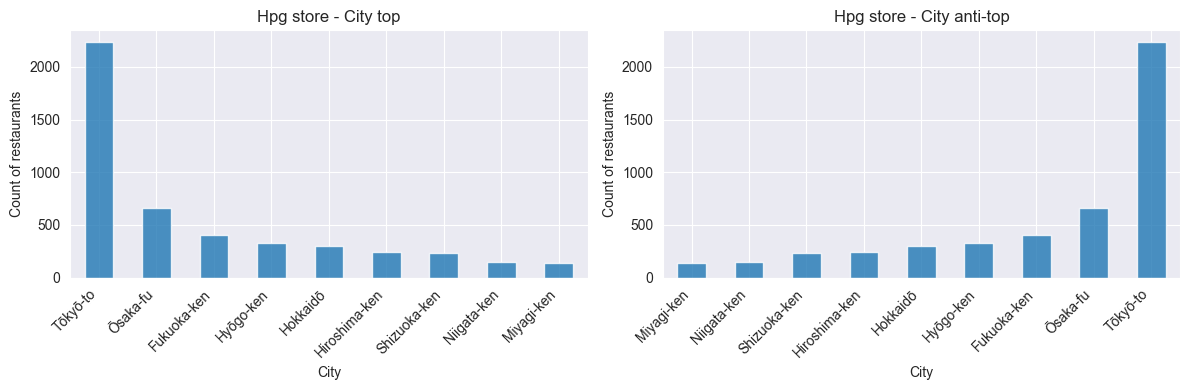

In [72]:
plot_top_genres_cities(hpg_store_df, HPG_STORE_STR, HPG_GENRE_COL, "city")

## Seasonal plots

### Hpg reserve df

It is necessary to research count of bookings depending on the day of the week and the month.

In [73]:
hpg_res_filled = add_seasonal_columns(hpg_res_filled, VISIT_DATE_COL)

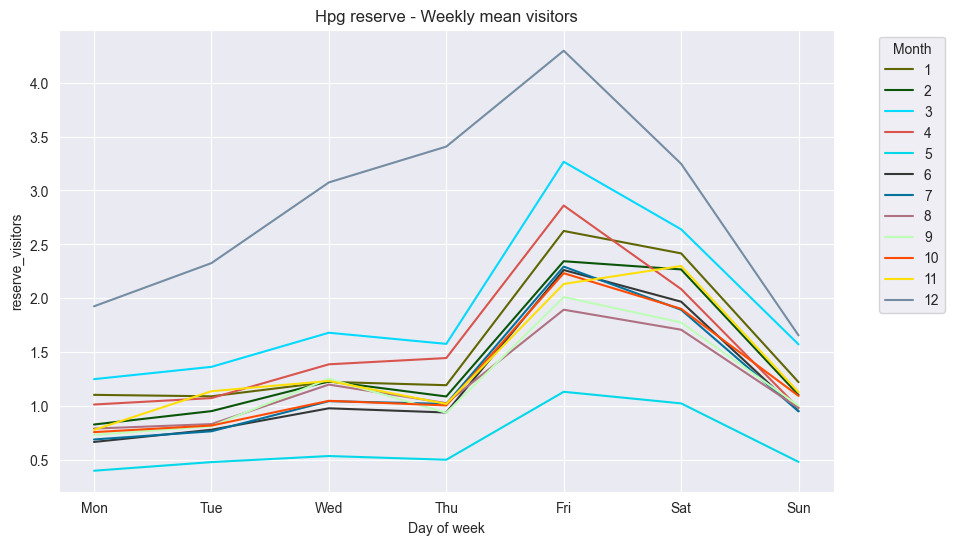

In [74]:
plot_weekly_seasonality(
    hpg_res_filled, RESERVE_VISITORS_COL, "Hpg reserve - Weekly mean visitors"
)

The number of visitors for Saturdays and Sundays is constantly declining. There are months, where the average number of visitors on weekdays is significantly higher than on other months.

### Air reserve df

It is necessary to research count of bookings depending on the day of the week and the month.

In [75]:
air_res_filled = add_seasonal_columns(air_res_filled, VISIT_DATE_COL)

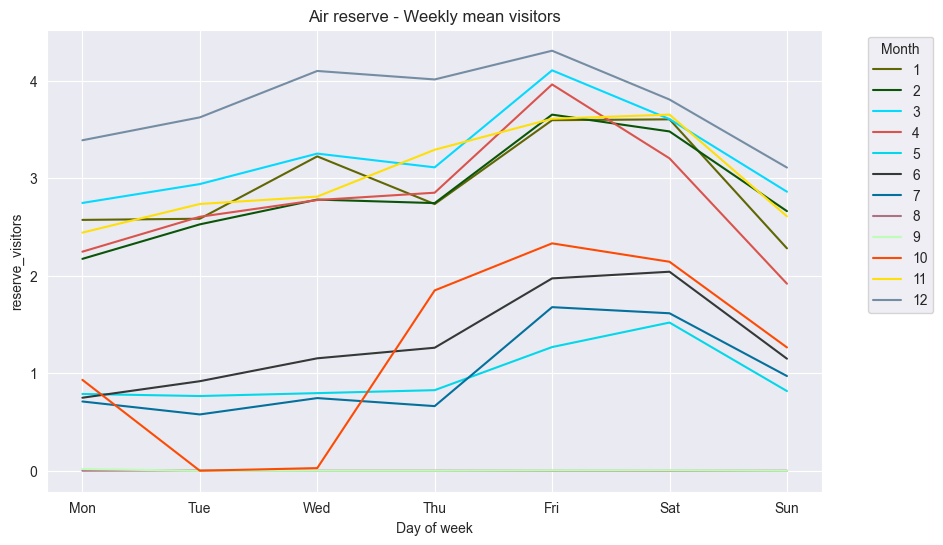

In [76]:
plot_weekly_seasonality(
    air_res_filled, RESERVE_VISITORS_COL, "Air reserve - Weekly mean visitors"
)

There is no specific seasonality. The eighth and ninth months are missing.

### Air visit data

In [77]:
air_visit_full = add_seasonal_columns(air_visit_full, VISIT_DATE_COL)

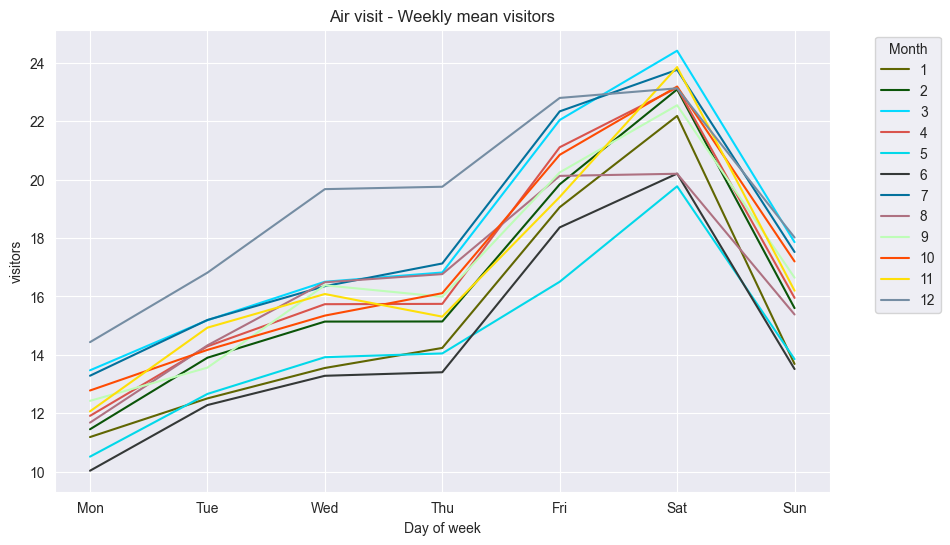

In [78]:
plot_weekly_seasonality(air_visit_full, VISITORS_COL, "Air visit - Weekly mean visitors")

The busiest hours are Friday through Sunday (and especially Saturday). There's some slight fluctuation by month, but the trend remains consistent.

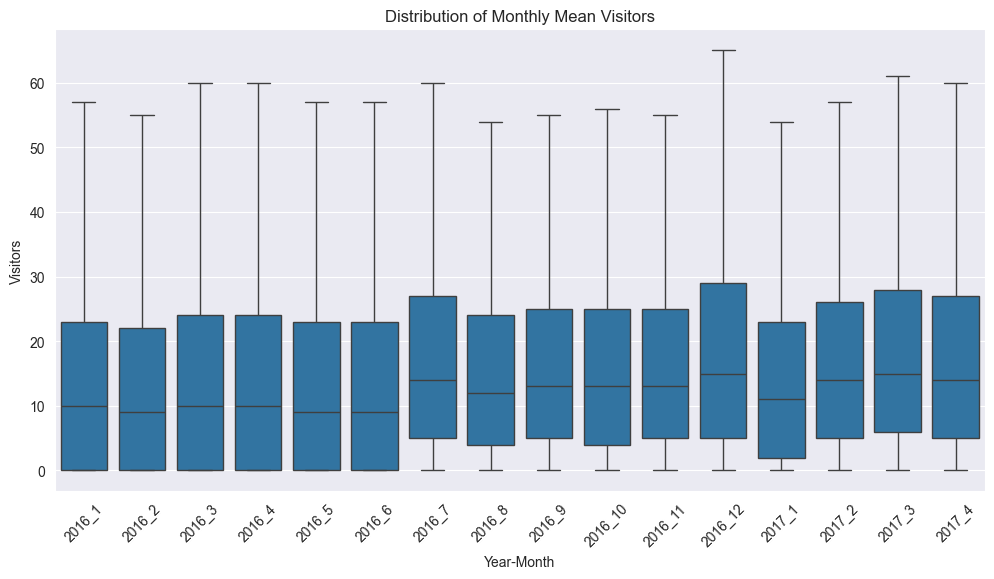

In [79]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=YEAR_MONTH_COL, y=VISITORS_COL, data=air_visit_full, showfliers=False)
plt.title("Distribution of Monthly Mean Visitors")
plt.xlabel("Year-Month")
plt.ylabel("Visitors")
plt.xticks(rotation=45)
plt.show()

The graph shows that the monthly average remains virtually unchanged, except for December, when demand increases.

In [80]:
air_vis_msd_per_df = add_seasonal_columns(air_vis_msd_per_df.reset_index(), VISIT_DATE_COL)

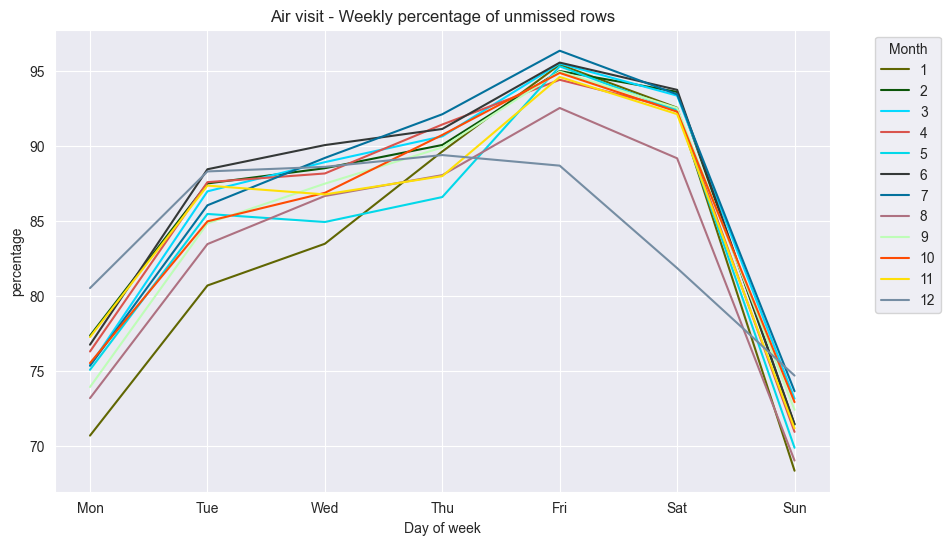

In [81]:
plot_weekly_seasonality(
    air_vis_msd_per_df, PERCENTAGE_COL, "Air visit - Weekly percentage of unmissed rows"
)

There is a clear seasonality in the missing data, likely related to the establishments' operating hours. Sundays have the highest percentage of missing data, while Fridays and Saturdays have the lowest.

In [82]:
del air_vis_msd_per_df

### Air visit & Date info

It is necessary to indicate the number of days before/after the holiday.

In [83]:
dates_with_holidays = add_holiday_columns(date_info_df, CALENDAR_DATE_COL)
dates_occurred_df, _ = split_reserve_by_date(
    dates_with_holidays, min_sample_date, CALENDAR_DATE_COL
)
dates_with_holidays.head()

,calendar_date,day_of_week,holiday_flg,days_from_holiday
0,2016-01-01,Friday,1,0
1,2016-01-02,Saturday,1,0
2,2016-01-03,Sunday,1,0
3,2016-01-04,Monday,0,1
4,2016-01-05,Tuesday,0,2


In [84]:
air_visit_mean_visitors = air_visit_full.groupby(VISIT_DATE_COL)[VISITORS_COL].mean()
air_vis_mean_hol_merged = (
    air_visit_mean_visitors.reset_index()
    .merge(
        dates_occurred_df,
        how="right",
        left_on=VISIT_DATE_COL,
        right_on=CALENDAR_DATE_COL,
    )
    .drop(VISIT_DATE_COL, axis=1)
    .rename(columns={CALENDAR_DATE_COL: VISIT_DATE_COL})
    .fillna(0)
)
air_vis_mean_hol_merged.head()

,visitors,visit_date,day_of_week,holiday_flg,days_from_holiday
0,21.081633,2016-01-01,Friday,1,0
1,20.511628,2016-01-02,Saturday,1,0
2,20.591304,2016-01-03,Sunday,1,0
3,16.630000,2016-01-04,Monday,0,1
4,13.876325,2016-01-05,Tuesday,0,2


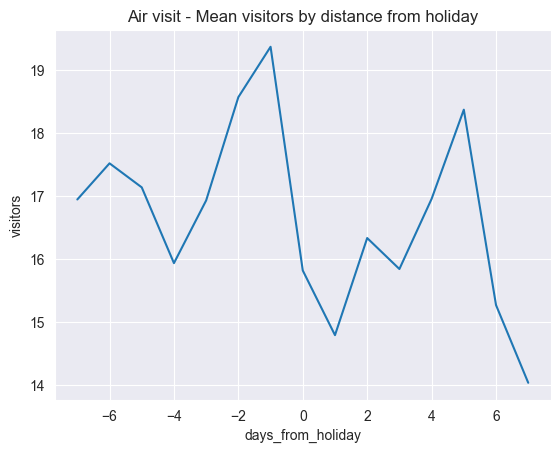

In [85]:
air_mean_vis_by_hol = air_vis_mean_hol_merged.groupby(DAYS_FROM_HOL_COL)[VISITORS_COL].mean()
n_range = 7
air_mean_vis_by_hol_lim = air_mean_vis_by_hol[
    (air_mean_vis_by_hol.index >= -n_range) & (air_mean_vis_by_hol.index <= n_range)
]

air_mean_vis_by_hol_lim.plot()
plt.xlabel(DAYS_FROM_HOL_COL)
plt.ylabel(VISITORS_COL)
plt.title(f"{AIR_VISIT_STR} - Mean visitors by distance from holiday")
plt.show()

The day before the holiday and on the holiday itself, the average number of visitors increases sharply. The following day, the average drops sharply, after which it gradually returns to normal.

In [86]:
del dates_with_holidays, dates_occurred_df, air_vis_mean_hol_merged, air_mean_vis_by_hol, air_mean_vis_by_hol_lim

## Correlation

### Air visit acf

In [87]:
air_visit_acf = compute_acf(air_visit_mean_visitors, VISITORS_COL, nlags=30)
air_visit_acf

,ACF
Lag,
1,0.530233
2,-0.064820
3,-0.189740
4,-0.199331
5,-0.090306
6,0.435337
7,0.794250
8,0.391245
9,-0.141252


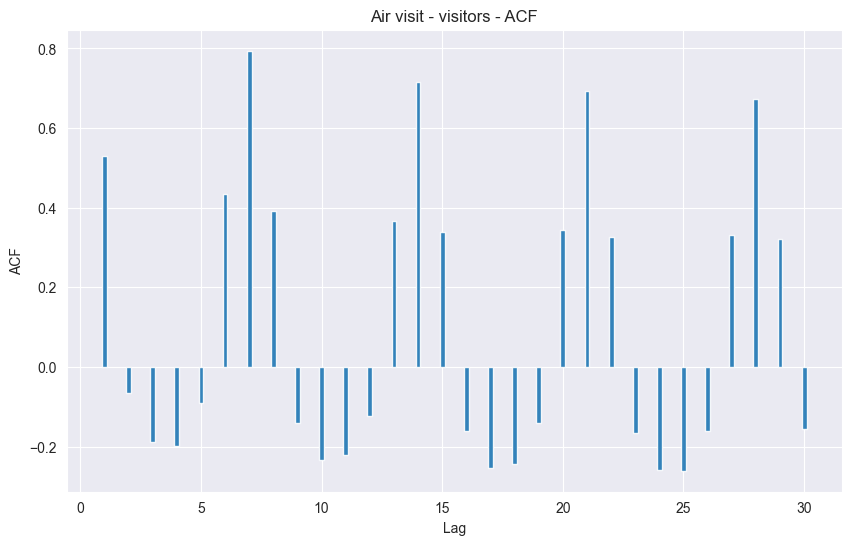

In [88]:
plot_acf(air_visit_acf, VISITORS_COL, AIR_VISIT_STR)

Lag 1 shows a moderate positive correlation, while every 7th lag shows a strong positive correlation. Every 6th and 8th lag shows a weak positive correlation. The remaining lags show either a strong weak negative, or weak negative correlation, and these correlations also repeat weekly. That is, the feature has its strongest influence on the same day of the previous week.

In [89]:
del air_visit_mean_visitors, air_visit_acf

### Air reserve acf

So far I don't see the point in autocorrelation due to the large gaps in the August-September data.

### Hpg reserve acf

In [90]:
hpg_reserve_acf = compute_acf(
    hpg_res_filled.groupby(VISIT_DATE_COL)[RESERVE_VISITORS_COL].mean(),
    RESERVE_VISITORS_COL,
    nlags=30
)
hpg_reserve_acf

,ACF
Lag,
1,0.587154
2,0.214032
3,0.106460
4,0.114819
5,0.231369
6,0.537642
7,0.771996
8,0.417180
9,0.090204


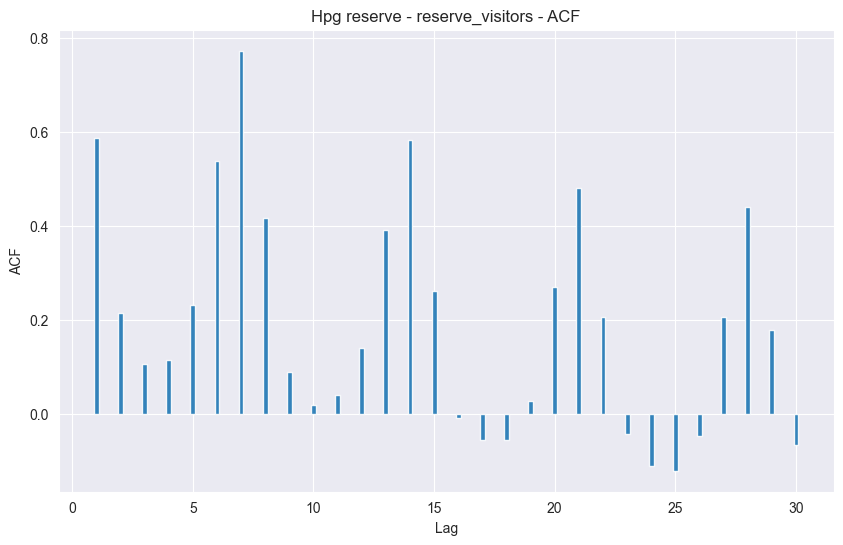

In [91]:
plot_acf(hpg_reserve_acf, RESERVE_VISITORS_COL, HPG_RESERVE_STR)

Lags 1 and 7 are approximately equal in magnitude and are moderately positive correlated, almost strongly positive. Lags 2 through 5 are weakly positive correlated, and Lag 6 is also moderately positive, but still has less influence than Lags 1 and 7. The remaining Lags are very small (except for those multiples of seven).

In [92]:
del hpg_reserve_acf

### Air visit & reservations

In [93]:
hpg_res_sum = add_sum_of_reserves(hpg_res_occurred_df, RESERVE_HPG_COL, HPG_RESTAURANT_ID_COL)
hpg_res_sum = hpg_res_sum.merge(
    hpg_store_df[[HPG_RESTAURANT_ID_COL, CITY_COL]], on=HPG_RESTAURANT_ID_COL
)
hpg_res_sum = add_nbrs_reserves(hpg_res_sum, RESERVE_HPG_COL, CITY_COL, RESERVE_HPG_NBR_COL)
hpg_res_sum = hpg_res_sum.merge(store_id_rel_df, on=HPG_RESTAURANT_ID_COL)

In [94]:
air_res_sum = add_sum_of_reserves(air_res_occurred_df, RESERVE_AIR_COL)
air_res_sum = air_res_sum.merge(
    air_store_df[[AIR_RESTAURANT_ID_COL, CITY_COL]], on=AIR_RESTAURANT_ID_COL
)
air_res_sum = add_nbrs_reserves(air_res_sum, RESERVE_AIR_COL, CITY_COL, RESERVE_AIR_NBR_COL)

In [109]:
air_with_res = add_total_reserves(air_vis_with_info, air_res_sum, hpg_res_sum, CITY_COL)
air_with_res = add_total_nbr_reserves(air_with_res, hpg_res_sum, CITY_COL)
air_with_res[[VISITORS_COL, TOTAL_RES_COL, TOTAL_RES_NBR_COL]].corr()

,visitors,total_reservations,total_reservations_nbrs
visitors,1.000000,0.177016,0.213336
total_reservations,0.177016,1.000000,0.558516
total_reservations_nbrs,0.213336,0.558516,1.000000


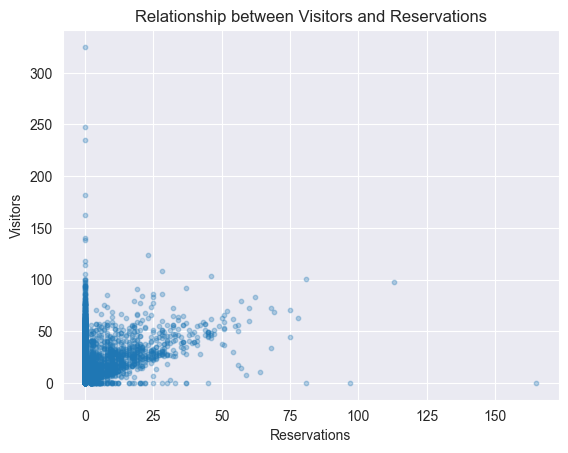

In [145]:
sample = air_with_res.sample(10000, random_state=RANDOM_SEED)
plot_vis_res_rel(sample[VISITORS_COL], sample[TOTAL_RES_COL])

Overall, the correlation between visitors and reservations is weak. The correlation with regular reservations (not from neighboring restaurants) is slightly weaker, as half of the restaurants have no reservation information (always 0). The graph shows that the correlation is weak due to restaurants with 0 reservations, but overall there is a trend.

## Possible features

Restaurant-level features (from air_store_info):

- Operating schedule - regular working days, extracted from the regular gaps in the data frame. I don't plan to include the hours, as not all restaurants have information on the level corresponding to their opening hours.

By neighbors, I want to designate restaurants that are located in the same air_area_name. Or I could use the same area, the same genre, but since there are rare genres, it turns out there won't be any neighbors at all. Comparing areas in hpg and air will provide much more information about reservations in the area for that day.

Per-visit features (air_visit):

- Number of visitors on this day last month for this restaurant.
- Lag 1, 7, 28 of the number of visitors - for this restaurant/for all/for neighbors.
- Missing lag indicator.
- Rolling mean/median/std of visitors over the past week, month - for this restaurant/for all/for neighbors.

- Indicator of whether the restaurant has been open within the last 6 months.
- Days since last recorded visit.
-
- Historical day-of-week mean/median up to (but not including) the current day - for this restaurant/for neighbors.

- Total reserved visitors (from air_reserve and hpg_reserve) on this day - for this restaurant/for neighbors.
- Difference between the number of visitors by reservation and the number of visitors who showed up. - We discussed this earlier, but we can't know what the difference will be for the predicted day.
- Rolling cancellation rate over the past 7 / 28 days - for this restaurant/for all/for neighbors.

- Days to/from the nearest holiday (negative is days until, positive is days after)
- Holiday indicator (currently included in date_info).
- Separate indicators for Golden Week dates.

- Smoothed target encoding of mean visitors by air_area_name.
- Smoothed target encoding of mean visitors by air_genre_name.

- Daily temperature - try to get the weather forecast.
- Precipitation probability.

Decomposition features:
- Trend.
- Trend difference for last month.
- Seasonal.
- Residual mean for last month.

## Conclusion

The percentage of air restaurant IDs that have information about air reservations is less than half. There are far fewer hpg restaurants with store information than with reservation data.

For restaurant reservation dataframes (air_reserve, hpg_reserve), the dates of visits that have already occurred and those that will occur are mixed, meaning that the number of visitors on these dates will need to be forecasted. Therefore, tables needed to be split into two parts. Some restaurants registered in air_store are not registered in hpg_store. The hpg system has slightly more areas than the air system. There are also twice as many genres.

It is necessary to forecast the data for 821 restaurants, of which 150 have information in the hpg system.

#### Missing values

There are no null values in the data, but there are missing rows on certain dates for certain restaurants. In **hpg_store** and **air_store** only 150 ids match, while in air_store (and air_visit) there are 829 IDs. In hph_store there are 4690 IDs, also 13325 in hpg_reserve.

- In the **air_visit** dataframe a large number of restaurants did not open immediately (in January 2016), but began somewhat later after the minimum visit date. The month with the highest frequency of openings was July 2016. Almost all restaurants are mentioned for the last time on the latest possible date, but there are also a small number that closed much earlier. Missing dates are seasonal (possibly restaurant opening hours). In January 2017, there was a drop and spike.
- In the **air_reserve** dataframe some restaurants are mentioned for the first time already in the predicted data. Most restaurants are last mentioned either on the earliest possible date that has already occurred, or during the dates for which data needs to be forecasted. However, there are quite a few restaurants that closed during the entire time period. Data for the period 2016-08 - 2016-10 is not available due to technical reasons.
- In the **hpg_reserve** dataframe most of the restaurants first mentioned early (January 2016), but some still mentioned later. Here, as in the air_reserve dataframe, most restaurants are last mentioned on the last dates or on the dates for which forecast data is needed. There are also restaurants that closed during the entire time period, but their percentage is quite small compared to air reserve.
- The **date_info** dataframe contains information about all dates presented in the dataset.

Since the air_reserve dataframe is missing a significant amount of data, it can be filled using the hpg_reserve dataframe. The average of the existing dates in these tables correlates with a coefficient of 0.6288.

#### Problematic data

1781 records were found for merged air_visit and air_reserved dataframes where the number of visitors in the reservations exceeded the total number of visitors for the day for individual restaurants, 5288 - for merged air_visit and hpg_reserved. For the intersection of air_visit, air_reserve, and hpg_reserve, 8181 such rows were found. However, it is impossible to claim that all of them are truly incorrect, as air_reserve and hpg_reserve may have overlapping reservations (at least the opposite hasn't been said).

It turns out that usually more people actually come to the restaurant than were booked.

- In the **air_reserve** df there are no rows where the reservation datetime is greater than the visit datetime.
- In the **hpg_reserve** df there are no rows where the reservation datetime is greater than the visit datetime.

Absolutely all restaurants whose IDs are presented in both the air and hpg dataframes have discrepancies, at least in genre or area, in these two dataframes.

#### Time plots

- In the **air_visit** dataframe, there is some slight fluctuation by month, but the trend remains consistent. The distribution of the average number of visitors by day is possibly multimodal. This may be due to the influence of holidays and non-holidays.
- In the **air_reserve** dataframe, from August 2016 to the end of October 2016, there were no reservations. After this period, the average number of reserved visitors remained the same, but the number of reservations increased compared with the period before the gap.
- In the **hpg_reserve** dataframe, in April 2016 and 2017, and December 2017, there were spikes in the average number of visitors per day. In January there is a sharp drop (for a couple of days), after which the values return to normal. There is seasonality for count of reservations per day, but December 2017 shows a significant spike. By January 2017, the values return to normal, but over time until April they gradually increase on average.
- In the **air_store_info** dataframe, restaurants are distributed roughly equally across the islands of Japan. At least three genres lag far behind others in popularity (number of restaurants): Asian, Karaoke/Party, and International cuisine. At the same time, about half of the areas have a maximum of 2 restaurants, while the maximum number of restaurants per area is about 60. So the best solution would be to take not the entire area, but only the city and region or only the city.
- In the **hpg_store_info** dataframe, restaurants are distributed roughly equally across the islands of Japan, with slightly more of them in the south. Just under 10 percent of areas have a maximum of 2 restaurants, while just over 20 have a maximum of 5. Meanwhile, the maximum number of restaurants per area is about 250.

#### Seasonality

- In the **air_visit** df there is a weekly seasonality in the data. Also, the busiest days are Friday through Sunday (and especially Saturday). The monthly visitors average remains virtually unchanged, except for December, when demand increases. There is a weekly seasonality in the missing data, likely related to the establishments' operating hours. Sundays have the highest percentage of missing data, while Fridays and Saturdays have the lowest.
- In the **air_reserve** df there is no specific seasonality.
- In the **hpg_reserve** the number of visitors for Saturdays and Sundays is constantly declining. There are months, where the average number of visitors on weekdays is significantly higher than on other months.
- In the **air_visit** merged with **date_info**, the day before the holiday and on the holiday itself, the average number of visitors increases sharply. The following day, the average drops sharply, after which it gradually returns to normal.

#### Autocorrelation

- For **air_visit** df lag 1 shows a moderate positive correlation, while every 7th lag shows a strong positive correlation. Every 6th and 8th lag shows a weak positive correlation. The remaining lags show either a strong weak negative, or weak negative correlation, and these correlations also repeat weekly. That is, the feature has its strongest influence on the same day of the previous week.
- For **hpg_reserve** df lags 1 and 7 are approximately equal in magnitude and are moderately positive correlated, almost strongly positive. Lags 2 through 5 are weakly positive correlated, and Lag 6 is also moderately positive, but still has less influence than Lags 1 and 7. The remaining Lags are very small (except for those multiples of seven).